In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import ruamel.yaml
import math
import numpy as np
import tarfile
from matplotlib import cm
from matplotlib import pyplot as plt
import warnings
import yaml
yaml_format = ruamel.yaml.YAML()
warnings.filterwarnings('ignore')
from matplotlib.ticker import FuncFormatter  # Add this import at the top
import pickle  # Add this import at the top
import matplotlib.ticker as mticker


import matplotlib.ticker as ticker  # Add this import at the top
OUTPUT_DIR = './figures'

app_name_mapping = {
    'ones-npb-ft': 'NPB-FT',
    'ones-npb-is': 'NPB-IS',
    'ones-stream-triad': 'Stream-Triad',
    'ones-stream-scale': 'Stream-Scale',
    'ones-stream-copy': 'Stream-Copy',
    'ones-stream-add': 'Stream-Add',
    'ones-stream-full': 'Stream-Full',
    'ones-npb-ep': 'NPB-EP',
    'phases-stream-full': 'Stream-Phase',
    'ones-npb-mg': 'NPB-MG',
    'ones-npb-cg': 'NPB-CG',
    'ones-npb-bt': 'NPB-BT'
}

In [ ]:
def get_data_dir(subfolder):
    # current_dir = os.path.dirname(os.path.abspath(__file__))
    current_dir = os.getcwd()
    print(current_dir)
    return os.path.join(current_dir, "experiment_data", subfolder)


In [ ]:
def derived_papi(PAPI_data):
    DERIVED = {}
    min_length = min(len(PAPI_data['PAPI_TOT_INS']['instantaneous_value']), len(PAPI_data['PAPI_TOT_CYC']['instantaneous_value']))
    DERIVED['TOT_INS_PER_CYC'] = pd.DataFrame({
        'value': np.array(PAPI_data['PAPI_TOT_INS']['instantaneous_value'][:min_length]) / np.array(PAPI_data['PAPI_TOT_CYC']['instantaneous_value'].iloc[:min_length]),
        'timestamp': np.array(PAPI_data['PAPI_TOT_INS'].time)
    })
    DERIVED['TOT_CYC_PER_INS'] = pd.DataFrame({
        'value': np.array(PAPI_data['PAPI_TOT_CYC']['instantaneous_value']) / np.array(PAPI_data['PAPI_TOT_INS']['instantaneous_value']),
        'timestamp': np.array(PAPI_data['PAPI_TOT_CYC'].time)
    })
    DERIVED['L3_TCM_PER_TCA'] = pd.DataFrame({
        'value': np.array(PAPI_data['PAPI_L3_TCM']['instantaneous_value']) / np.array(PAPI_data['PAPI_L3_TCA']['instantaneous_value']),
        'timestamp': np.array(PAPI_data['PAPI_L3_TCM'].time)
    })  
    DERIVED['TOT_STL_PER_CYC'] = pd.DataFrame({
        'value': np.array(PAPI_data['PAPI_RES_STL']['instantaneous_value']) / np.array(PAPI_data['PAPI_TOT_CYC']['instantaneous_value']),
        'timestamp': np.array(PAPI_data['PAPI_RES_STL'].time)
    })
    
    # Create a mask for non-NaN values across all keys
    mask = ~DERIVED['TOT_INS_PER_CYC']['value'].isna()  # Start with one key to create the mask
    for key in DERIVED:
        mask &= ~DERIVED[key]['value'].isna()  # Combine masks for all keys

    for key in DERIVED:
        DERIVED[key] = DERIVED[key][mask]  # Filter each DataFrame using the combined mask

    return DERIVED

def collect_power(power_data):
    power={}
    power['geopm_0'] = power_data[power_data.scope==0]
    power['geopm_1'] = power_data[power_data.scope==1]
    power['geopm_0']['elapsed_time'] = power['geopm_0']['time'] - power['geopm_0']['time'].iloc[0]
    power['geopm_1']['elapsed_time'] = power['geopm_1']['time'] - power['geopm_1']['time'].iloc[0]
    
    min_length = min(len(power['geopm_0']), len(power['geopm_1']))
    geopm_power_0 = power['geopm_0'][:min_length]
    geopm_power_1 = power['geopm_1'][:min_length]

    average_power = pd.DataFrame({
        'time_stamp': geopm_power_0['time'],  # Use the timestamp from geopm_power_0
        'average_power': [(p0 + p1) / 2 for p0, p1 in zip(geopm_power_0['value'], geopm_power_1['value'])]
    })
    average_power['elapsed_time'] = power['geopm_0']['elapsed_time']
    power['average_power'] = average_power
    return power

def calculate_power_with_wraparound(current, previous, time_diff, wraparound_value=262143.328850):
    diff = current - previous
    if diff < 0:  # Wraparound detected
        diff = (wraparound_value - previous) + current
    return diff / time_diff

def compute_power(pubEnergy,power_data=None):
    power = {}
    geopm_sensor0 = geopm_sensor1 = pd.DataFrame({'timestamp':[],'value':[]})
    for i,row in pubEnergy.iterrows():
        if i%2 == 0:
            geopm_sensor0 = pd.concat([geopm_sensor0, pd.DataFrame([{'timestamp': row['time'], 'value': row['value']}])], ignore_index=True)
        else:
            geopm_sensor1 = pd.concat([geopm_sensor1, pd.DataFrame([{'timestamp': row['time'], 'value': row['value']}])], ignore_index=True)


    power['geopm_power_0'] = pd.DataFrame({
        'timestamp': geopm_sensor0['timestamp'][1:],  # Add timestamps
        'power': [
            calculate_power_with_wraparound(
                geopm_sensor0['value'][i],
                geopm_sensor0['value'][i-1],
                geopm_sensor0['timestamp'][i] - geopm_sensor0['timestamp'][i-1]
            ) for i in range(1, len(geopm_sensor0))
        ]
    })

    # Apply the same logic to geopm_power_1
    power['geopm_power_1'] = pd.DataFrame({
        'timestamp': geopm_sensor1['timestamp'][1:],  # Add timestamps
        'power': [
            calculate_power_with_wraparound(
                geopm_sensor1['value'][i],
                geopm_sensor1['value'][i-1],
                geopm_sensor1['timestamp'][i] - geopm_sensor1['timestamp'][i-1]
            ) for i in range(1, len(geopm_sensor1))
        ]
    })

    min_length = min(len(power['geopm_power_0']), len(power['geopm_power_1']))
    geopm_power_0 = power['geopm_power_0'][:min_length]
    geopm_power_1 = power['geopm_power_1'][:min_length]
    # fig,axs = plt.subplots(3,1)
    # axs[0].plot(geopm_power_0['timestamp'], geopm_power_0['power'], label='Node 0')
    # axs[1].plot(geopm_power_1['timestamp'], geopm_power_1['power'], label='Node 1')

    average_power = pd.DataFrame({
        'timestamp': geopm_power_0['timestamp'],  # Use the timestamp from geopm_power_0
        'average_power': [(p0 + p1) / 2 for p0, p1 in zip(geopm_power_0['power'], geopm_power_1['power'])]
    })
    average_power['elapsed_time'] = average_power['timestamp'] - average_power['timestamp'].iloc[0]
    # axs[2].plot(average_power['timestamp'], average_power['average_power'], label='Average Power', color='green')
    power['average_power'] = average_power
    return power

def measure_progress(progress_data, energy_data):
    Progress_DATA = {} 
    progress_sensor = pd.DataFrame(progress_data)
    first_sensor_point = min(energy_data['average_power']['timestamp'].iloc[0], progress_sensor['time'][0])
    progress_sensor['elapsed_time'] = progress_sensor['time'] - first_sensor_point  # New column for elapsed time
    # progress_sensor = progress_sensor.set_index('elapsed_time')
    performance_elapsed_time = progress_sensor.elapsed_time
    # Add performance_frequency as a new column in progress_sensor
    frequency_values = [
        progress_data['value'].iloc[t] / (performance_elapsed_time[t] - performance_elapsed_time[t-1]) for t in range(1, len(performance_elapsed_time))
    ]
    
    # Ensure the frequency_values length matches the index length
    frequency_values = [0] + frequency_values  # Prepend a 0 for the first index
    progress_sensor['frequency'] = frequency_values
    upsampled_timestamps= energy_data['average_power']['timestamp']
    
    # true_count = (progress_sensor['time'] <= upsampled_timestamps.iloc[0]).sum()

    progress_frequency_median = pd.DataFrame({'median': np.nanmedian(progress_sensor['frequency'].where(progress_sensor['time'] <= upsampled_timestamps.iloc[0])), 'timestamp': upsampled_timestamps.iloc[0]}, index=[0])
    for t in range(1, len(upsampled_timestamps)):
        progress_frequency_median = pd.concat([progress_frequency_median, pd.DataFrame({'median': [np.nanmedian(progress_sensor['frequency'].where((progress_sensor['time'] >= upsampled_timestamps.iloc[t-1]) & (progress_sensor['time'] <= upsampled_timestamps.iloc[t])))],
        'timestamp': [upsampled_timestamps.iloc[t]]})], ignore_index=True)
    progress_frequency_median['elapsed_time'] = progress_frequency_median['timestamp'] - progress_frequency_median['timestamp'].iloc[0]
    # Assign progress_frequency_median as a new column
    Progress_DATA['progress_sensor'] = progress_sensor
    Progress_DATA['progress_frequency_median'] = progress_frequency_median
    return Progress_DATA

def collect_papi(PAPI_data):
    PAPI = {}
    for scope in PAPI_data['scope'].unique():
        # Extract the string between the 3rd and 4th dots
        scope_parts = scope.split('.')
        if len(scope_parts) > 4:  # Ensure there are enough parts
            extracted_scope = scope_parts[3]
            # Aggregate the data for the extracted scope using pd.concat
            PAPI[extracted_scope] = PAPI_data[PAPI_data['scope'] == scope]
            instantaneous_values = [0] + [PAPI[extracted_scope]['value'].iloc[k] - PAPI[extracted_scope]['value'].iloc[k-1] for k in range(1,len(PAPI[extracted_scope]))]
            # Normalize the instantaneous values between 0 and 10
            # min_val = min(instantaneous_values)
            # max_val = max(instantaneous_values)
            PAPI[extracted_scope]['instantaneous_value'] = instantaneous_values
            PAPI[extracted_scope]['elapsed_time'] = PAPI[extracted_scope]['time'] - PAPI[extracted_scope]['time'].iloc[0]
    return PAPI


def generate_PCAP(PCAP_data):
    for row in PCAP_data.iterrows():
        if row[1]['time'] == 0:
            PCAP_data = PCAP_data.drop(row[0])


    PCAP_data['elapsed_time'] = PCAP_data['time'] - PCAP_data['time'].iloc[0]
    return PCAP_data


def compute_energy_consump(test_data_frame):
    total_energy = 0
    for i,t in enumerate(test_data_frame['average_power']['elapsed_time'].iloc[:-1]):
        total_energy += test_data_frame['average_power']['average_power'].iloc[i] * (test_data_frame['average_power']['elapsed_time'].iloc[i+1]-test_data_frame['average_power']['elapsed_time'].iloc[i])
    return total_energy


In [ ]:
DATA_DIR = get_data_dir('plotting_data')
root,folders,files = next(os.walk(DATA_DIR))
test_results = {}
for APP in folders:
    print(APP)
    APP_DIR = os.path.join(DATA_DIR, APP)
    test_results[APP] = {}
    for tar_file in next(os.walk(APP_DIR))[2]:
        test_results[APP][tar_file] = {}
        if tar_file.endswith('.tar'):
            tar_path = os.path.join(APP_DIR, tar_file)
            extract_dir = os.path.join(APP_DIR, tar_file[:-4])  
            
            if not os.path.exists(extract_dir):
                os.makedirs(extract_dir)
            
            with tarfile.open(tar_path, 'r') as tar:
                tar.extractall(path=extract_dir)
        
        pubProgress = pd.read_csv(f'{extract_dir}/progress.csv')
        pubEnergy = pd.read_csv(f'{extract_dir}/energy.csv')
        pubPAPI = pd.read_csv(f'{extract_dir}/papi.csv')
        pubPCAP = pd.read_csv(f'{extract_dir}/PCAP_file.csv')
        pubPower = pd.read_csv(f'{extract_dir}/measured_power.csv')

        test_results[APP][tar_file]['energy'] = pubEnergy
        test_results[APP][tar_file]['power'] = compute_power(pubEnergy)
        test_results[APP][tar_file]['progress'] = measure_progress(pubProgress,test_results[APP][tar_file]['power'])
        test_results[APP][tar_file]['papi'] = collect_papi(pubPAPI)
        test_results[APP][tar_file]['PCAP'] = generate_PCAP(pubPCAP)
        test_results[APP][tar_file]['derived_papi'] = derived_papi(test_results[APP][tar_file]['papi'])   
        test_results[APP][tar_file]['pubPower'] = pubPower
# print(test_results[APP][tar_file])

/home/cc/summer2024/main_codes
phases-stream-full
ones-stream-copy
ones-npb-cg
ones-npb-ep
ones-stream-add
ones-stream-scale
ones-npb-mg
ones-stream-full
ones-npb-ft
ones-stream-triad
ones-npb-bt
ones-npb-is


In [ ]:
# def compute_energy_consump(test_data_frame, start_time = None, end_time = None):
#     total_energy = 0
#     for i,t in enumerate(test_data_frame['average_power']['elapsed_time'].iloc[:-1]): # progress elapsed time not control elapsed time
#         total_energy += test_data_frame['average_power']['average_power'].iloc[i] * (test_data_frame['average_power']['elapsed_time'].iloc[i+1]-test_data_frame['average_power']['elapsed_time'].iloc[i])
#     return total_energy


def compute_energy_consump(test_data_frame, start_time=None, end_time=None):
    total_energy = 0
    for i in range(len(test_data_frame['average_power']['elapsed_time']) - 1):
        current_timestamp = test_data_frame['average_power']['timestamp'].iloc[i]
        if start_time is not None and end_time is not None:
            if start_time <= current_timestamp <= end_time:
                total_energy += (
                    test_data_frame['average_power']['average_power'].iloc[i]
                    * (
                        test_data_frame['average_power']['elapsed_time'].iloc[i + 1]
                        - test_data_frame['average_power']['elapsed_time'].iloc[i]
                    )
                )
        else:
            total_energy += (
                test_data_frame['average_power']['average_power'].iloc[i]
                * (
                    test_data_frame['average_power']['elapsed_time'].iloc[i + 1]
                    - test_data_frame['average_power']['elapsed_time'].iloc[i]
                )
            )
    return total_energy

DATA_DIR = get_data_dir('Control_evaluation')
root,folders,files = next(os.walk(DATA_DIR))
test_results_control = {}
for APP in folders:
    APP_DIR = os.path.join(DATA_DIR, APP)
    test_results_control[APP] = {}
    for file in next(os.walk(APP_DIR))[2]:
        print("application:",APP,"file:",file)
        test_results_control[APP][file] = {}
        if file.endswith('.tar'):
            tar_path = os.path.join(APP_DIR, file)
            extract_dir = os.path.join(APP_DIR, file[:-4])  
            
            if not os.path.exists(extract_dir):
                os.makedirs(extract_dir)
            
            with tarfile.open(tar_path, 'r') as tar:
                tar.extractall(path=extract_dir)
            
        pubProgress = pd.read_csv(f'{extract_dir}/progress.csv')
        pubEnergy = pd.read_csv(f'{extract_dir}/energy.csv')
        pubPAPI = pd.read_csv(f'{extract_dir}/papi.csv')
        pubPCAP = pd.read_csv(f'{extract_dir}/PCAP_file.csv')
        pubPower = pd.read_csv(f'{extract_dir}/measured_power.csv')
        test_results_control[APP][file]['energy'] = pubEnergy
        test_results_control[APP][file]['power'] = compute_power(pubEnergy,power_data=pubPower)
        test_results_control[APP][file]['progress'] = measure_progress(pubProgress,test_results_control[APP][file]['power'])
        test_results_control[APP][file]['papi'] = collect_papi(pubPAPI)
        test_results_control[APP][file]['PCAP'] = generate_PCAP(pubPCAP)
        test_results_control[APP][file]['derived_papi'] = derived_papi(test_results_control[APP][file]['papi'])   
        test_results_control[APP][file]['pubPower'] = pubPower


/home/cc/summer2024/main_codes
application: phases-stream-full file: compressed_iteration_20251111_053427.tar
application: phases-stream-full file: compressed_iteration_20251111_060616.tar
application: phases-stream-full file: compressed_iteration_20251111_055040.tar
application: ones-stream-copy file: compressed_iteration_20251111_054032.tar
application: ones-stream-copy file: compressed_iteration_20251111_055644.tar
application: ones-stream-copy file: compressed_iteration_20251111_052347.tar
application: ones-npb-cg file: compressed_iteration_20251111_053018.tar
application: ones-npb-cg file: compressed_iteration_20251111_060207.tar
application: ones-npb-cg file: compressed_iteration_20251111_054633.tar
application: ones-npb-ep file: compressed_iteration_20251111_054419.tar
application: ones-npb-ep file: compressed_iteration_20251111_060028.tar
application: ones-npb-ep file: compressed_iteration_20251111_052735.tar
application: ones-stream-add file: compressed_iteration_20251111_0524

In [ ]:
for app in test_results.keys():
    if 'ones-npb-bt' in app:
        for trace in test_results[app].keys():
            execution_time = test_results[app][trace]['progress']['progress_sensor']['elapsed_time'].iloc[-1]
            if execution_time > 250:
                print(f"Deleting {trace} because execution time is {execution_time}")
                os.system(f"rm -rf /home/cc/summer2024/main_codes/experiment_data/plotting_data/{app}/{trace}")

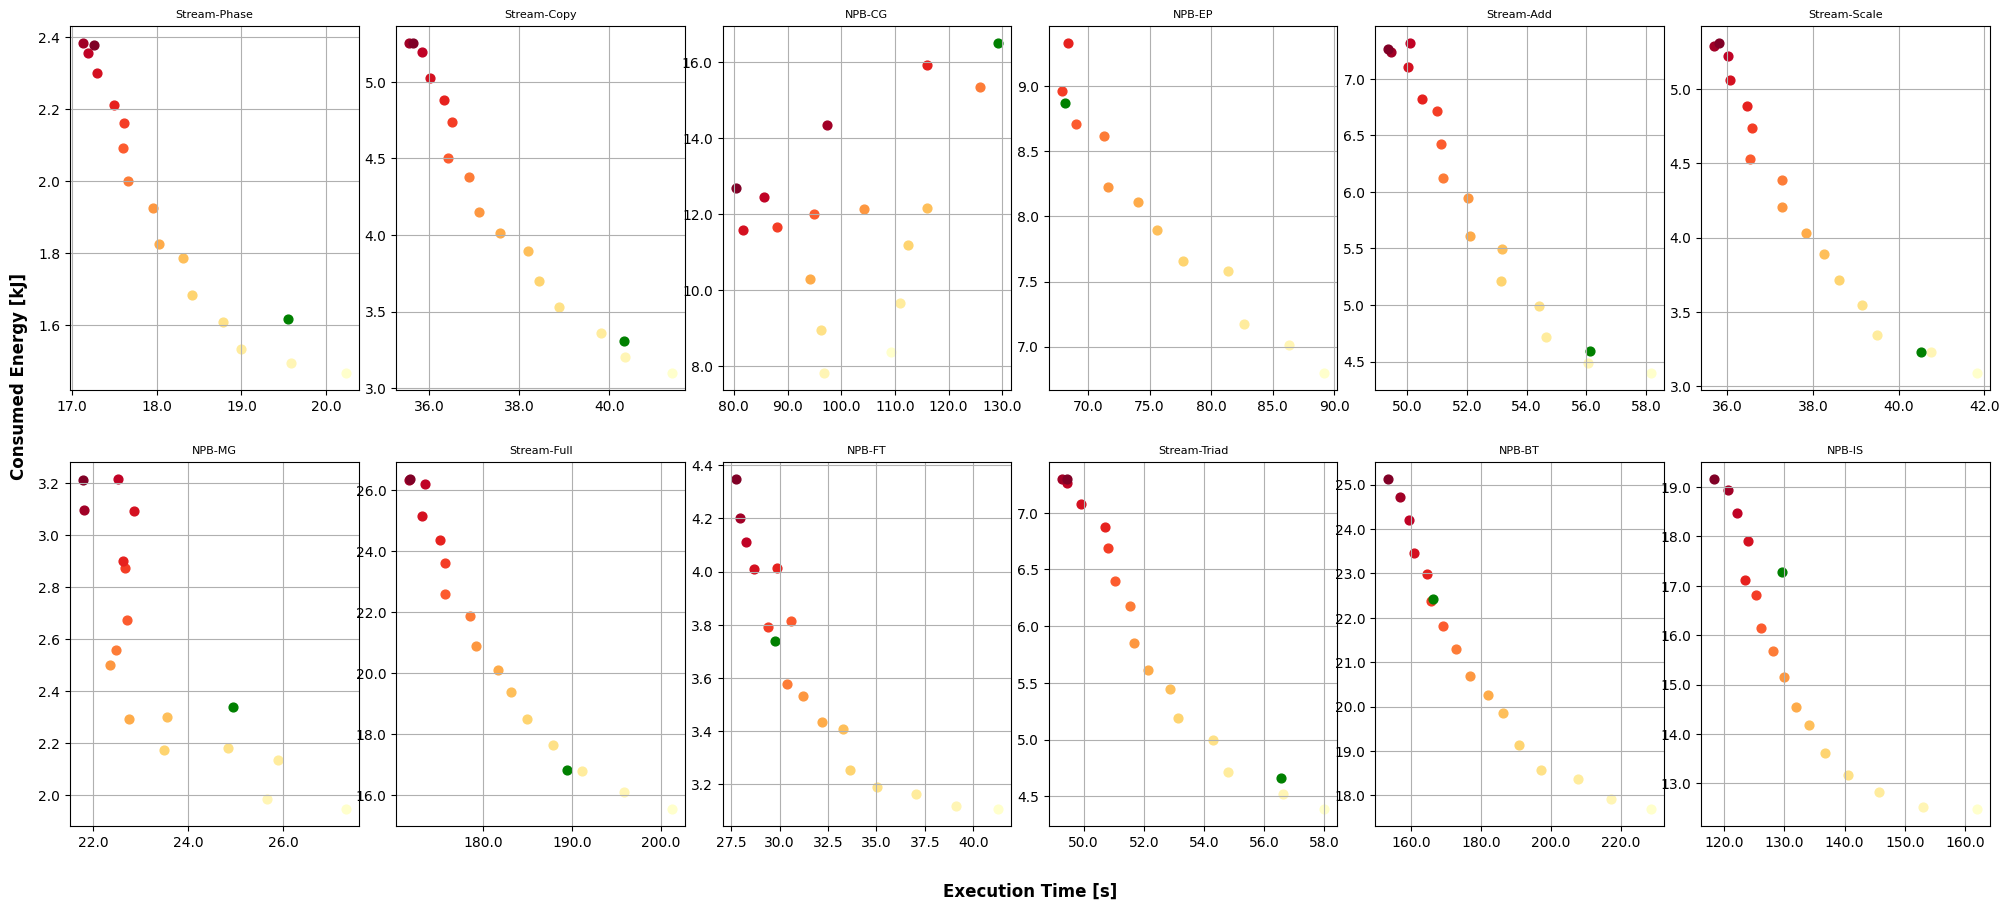

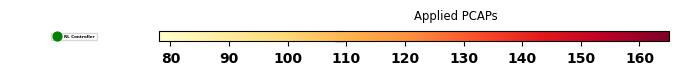

In [ ]:
# print(test_results)
# Set up the plot layout with 2 rows and 5 columns
marker_size = 40
num_rows = 2
num_cols = 6
fig, axs = plt.subplots(num_rows, num_cols, figsize=(20, 10))  # Adjusting figsize for 2 rows and 5 columns
plt.rcParams.update({'font.size': 10, "font.weight": "bold", 'axes.labelsize': 'small'})

# Adjusting left margin more aggressively to reduce the space on the left side
plt.subplots_adjust(hspace=0.2, wspace=0.13, top=0.85, bottom=0.05, left=0.02, right=0.98)  # Further reduced left margin to 0.02
fig.text(0.5, -0.02, 'Execution Time [s]', ha='center', fontsize=12)
fig.text(-0.01, 0.5, 'Consumed Energy [kJ]', va='center', rotation='vertical', fontsize=12)
index = 0

high_contrast_colors = plt.cm.YlOrRd(np.linspace(0, 1, 16))
sorted_keys = [78.0, 83.0, 89.0, 95.0, 101.0, 107.0, 112.0, 118.0, 124.0, 130.0, 136.0, 141.0, 147.0, 153.0, 159.0, 165.0]
norm = plt.Normalize(vmin=min(sorted_keys), vmax=max(sorted_keys)) 
smappable = plt.cm.ScalarMappable(cmap='YlOrRd', norm=norm)
smappable.set_array([])  # Dummy array to initiate ScalarMappable (not used to plot)



from collections import defaultdict
for app in test_results.keys():
    grouped_traces = defaultdict(list)
    # max_execution_time = max([test_results[app][trace]['power']['average_power']['elapsed_time'].iloc[-1] for trace in test_results[app].keys()])
    # max_energy_consumption = max([compute_energy_consump(test_results[app][trace]['power'])/1000 for trace in test_results[app].keys()])
    max_execution_time = 1
    max_energy_consumption = 1
    for trace in test_results[app].keys():
        grouped_traces[test_results[app][trace]['PCAP'].value.mean()].append(trace)
        # computed_energy = compute_energy_consump(test_results[app][trace]['power'])/1000
        # axs[index//num_cols, index%num_cols].scatter(test_results[app][trace]['power']['average_power']['elapsed_time'].iloc[-1],computed_energy, color=high_contrast_colors[0], s=10, label = "Static PCAP")
        # if "ones-stream-triad" in app and (test_results[app][trace]['power']['average_power']['elapsed_time'].iloc[-1] > 80) and computed_energy > 8:
        #     print(trace)
    # print(grouped_traces.keys())
    for i,PCAP_traces in enumerate(sorted(grouped_traces.keys())):     
        # print(app,trace) 
        # if app == 'ones-stream-add':
        #     pass  
        energy_list = []
        for PCAP_trace in grouped_traces[PCAP_traces]:
            start_time = test_results[app][PCAP_trace]['progress']['progress_sensor'].time.iloc[0]
            end_time = test_results[app][PCAP_trace]['progress']['progress_sensor'].time.iloc[-1]
            energy = compute_energy_consump(test_results[app][PCAP_trace]['power'], start_time=start_time, end_time=end_time)
            energy_list.append(energy)
        computed_energy = np.mean(energy_list) / 1000                              
        # execution_time = np.mean([test_results[app][PCAP_trace]['power']['average_power']['elapsed_time'].iloc[-1] for PCAP_trace in grouped_traces[PCAP_traces]])
        execution_time = np.mean([test_results[app][PCAP_trace]['progress']['progress_sensor']['elapsed_time'].iloc[-1] for PCAP_trace in grouped_traces[PCAP_traces]])
        # print(computed_energy,execution_time)
        axs[index//num_cols, index%num_cols].scatter(execution_time/max_execution_time,computed_energy/max_energy_consumption,color=high_contrast_colors[i], s=marker_size)
    axs[index//num_cols, index%num_cols].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))  # Change format as needed
    axs[index//num_cols, index%num_cols].set_title(app_name_mapping.get(app, app), fontsize=8, loc='center')
    axs[index//num_cols, index%num_cols].grid(True)

    # index += 1
# index = 0
# for app in test_results_control.keys():
    # for trace in test_results_control[app].keys():
    computed_energy = np.mean([compute_energy_consump(test_results_control[app][trace]['power'])/1000 for trace in test_results_control[app].keys()])
    # execution_time = np.mean([test_results_control[app][trace]['power']['average_power']['elapsed_time'].iloc[-1] for trace in test_results_control[app].keys()]) # actuation
    execution_time = np.mean([test_results_control[app][trace]['progress']['progress_sensor']['elapsed_time'].iloc[-1] for trace in test_results_control[app].keys()])
    axs[index//num_cols, index%num_cols].scatter(execution_time/max_execution_time, computed_energy/max_energy_consumption, color='green', s=marker_size, label = "RL Controller")
    axs[index//num_cols, index%num_cols].yaxis.set_major_formatter(FuncFormatter(lambda x, _: round(x, 1)))    
    axs[index//num_cols, index%num_cols].xaxis.set_major_formatter(FuncFormatter(lambda x, _: round(x, 1)))  
    # axs[index//num_cols, index%num_cols].set_ylim(0.6, 1)
    # axs[index//num_cols, index%num_cols].set_xlim(0.65, 1)
    index += 1



handles, labels = axs[0,0].get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))     

# for i in range(num_rows):
#     for j in range(num_cols):
#         if j > 0:
#             axs[i, j].set_yticks(np.linspace(axs[i,j].get_ylim()[0], axs[i,j].get_ylim()[1], 5))
#             axs[i, j].set_yticklabels([])
#         else:
#             axs[i,j].set_yticks(np.linspace(axs[i,j].get_ylim()[0], axs[i,j].get_ylim()[1], 5))
#         if i == 0:
#             axs[i, j].set_xticklabels([])
plt.savefig(f'{OUTPUT_DIR}/comparison_mean.pdf', format='pdf', bbox_inches='tight')  # Save the figure

fig_leg, ax_leg = plt.subplots(figsize=(8.5,0.2))

ax_leg.legend(loc='center')

ax_leg.axis('off')
fig_leg.legend(unique_labels.values(), unique_labels.keys(), loc='center', ncol=1, bbox_to_anchor=(0.2, 0.5), fontsize=3)
cbar_ax = fig_leg.add_axes([0.3, 0.25, 0.6, 0.5]) 
cbar = plt.colorbar(smappable, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Applied PCAPs', labelpad=-40, horizontalalignment='left')

plt.savefig(f'{OUTPUT_DIR}/legend_only.pdf', format='pdf', bbox_inches='tight')
plt.show()



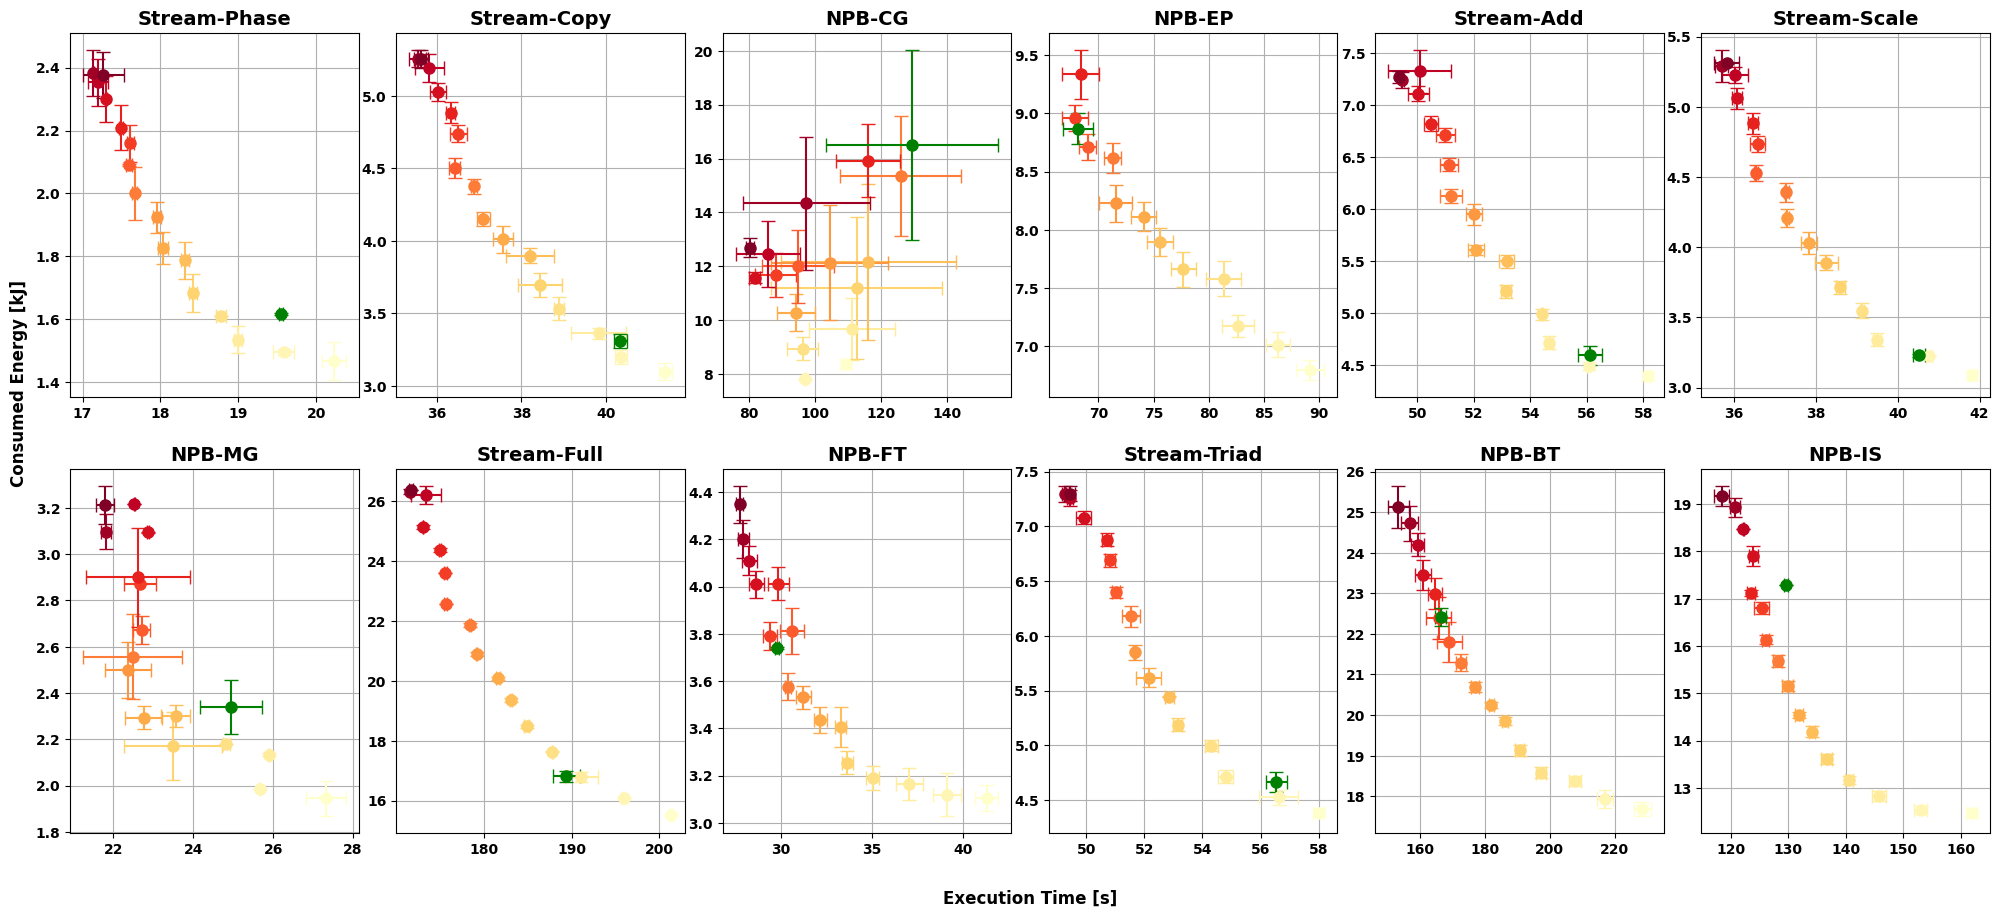

In [ ]:
marker_size = 40
num_rows = 2
num_cols = 6
fig, axs = plt.subplots(num_rows, num_cols, figsize=(20, 10))  # Adjusting figsize for 2 rows and 5 columns
plt.rcParams.update({'font.size': 10, "font.weight": "bold", 'axes.labelsize': 'small'})

# Adjusting left margin more aggressively to reduce the space on the left side
plt.subplots_adjust(hspace=0.2, wspace=0.13, top=0.85, bottom=0.05, left=0.02, right=0.98)
fig.text(0.5, -0.02, 'Execution Time [s]', ha='center', fontsize=12)
fig.text(-0.01, 0.5, 'Consumed Energy [kJ]', va='center', rotation='vertical', fontsize=12)
index = 0

high_contrast_colors = plt.cm.YlOrRd(np.linspace(0, 1, 16))
sorted_keys = [78.0, 83.0, 89.0, 95.0, 101.0, 107.0, 112.0, 118.0, 124.0, 130.0, 136.0, 141.0, 147.0, 153.0, 159.0, 165.0]
norm = plt.Normalize(vmin=min(sorted_keys), vmax=max(sorted_keys))
smappable = plt.cm.ScalarMappable(cmap='YlOrRd', norm=norm)
smappable.set_array([])

from collections import defaultdict

for app in test_results.keys():
    grouped_traces = defaultdict(list)
    for trace in test_results[app].keys():
        grouped_traces[test_results[app][trace]['PCAP'].value.mean()].append(trace)

    boxplot_data = []
    exec_time_means = []
    for i, PCAP_traces in enumerate(sorted(grouped_traces.keys())):
        energy_list = []
        exec_time_list = []
        for PCAP_trace in grouped_traces[PCAP_traces]:
            start_time = test_results[app][PCAP_trace]['progress']['progress_sensor'].time.iloc[0]
            end_time = test_results[app][PCAP_trace]['progress']['progress_sensor'].time.iloc[-1]
            energy = compute_energy_consump(test_results[app][PCAP_trace]['power'], start_time=start_time, end_time=end_time) / 1000
            exec_time = test_results[app][PCAP_trace]['progress']['progress_sensor']['elapsed_time'].iloc[-1]
            energy_list.append(energy)
            exec_time_list.append(exec_time)
        boxplot_data.append(energy_list)
        exec_time_means.append(np.mean(exec_time_list))

        # Calculate mean and std for this group
        energy_mean = np.mean(energy_list)
        energy_std = np.std(energy_list)
        exec_time_mean = np.mean(exec_time_list)
        exec_time_std = np.std(exec_time_list)

        # Overlay mean and std as error bars (use the same color as the box)
        color = high_contrast_colors[i % len(high_contrast_colors)]
        ax = axs[index//num_cols, index%num_cols]
        ax.errorbar(
            exec_time_mean, energy_mean,
            xerr=exec_time_std, yerr=energy_std,
            fmt='o', color=color, markersize=marker_size/5, capsize=5, zorder=5
        )
    # Remove PCAP labels from x-axis, use execution time as ticks
    # ax.set_xticks(exec_time_means)
    # ax.set_xticklabels([f"{x:.1f}" for x in exec_time_means], rotation=45, fontsize=8)
    ax.set_title(app_name_mapping.get(app, app), fontsize=14, loc='center', fontweight='bold')
    ax.grid(True)
    # ax.set_xlabel('Execution Time [s]')
    # ax.set_ylabel('Consumed Energy [kJ]')

    # Add RL Controller (control) mean and std as error bars
    energy_control = [
        compute_energy_consump(test_results_control[app][trace]['power']) / 1000
        for trace in test_results_control[app].keys()
    ]
    exec_time_control = [
        test_results_control[app][trace]['progress']['progress_sensor']['elapsed_time'].iloc[-1]
        for trace in test_results_control[app].keys()
    ]
    energy_mean_control = np.mean(energy_control)
    energy_std_control = np.std(energy_control)
    exec_time_mean_control = np.mean(exec_time_control)
    exec_time_std_control = np.std(exec_time_control)

    ax.errorbar(
        exec_time_mean_control, energy_mean_control,
        xerr=exec_time_std_control, yerr=energy_std_control,
        fmt='o', color='green', markersize=marker_size/5, label="RL Controller", capsize=5, zorder=5
    )

    index += 1
fig.savefig(f'{OUTPUT_DIR}/comparison_mean_std_dev.pdf', format='pdf', bbox_inches='tight')  # Save the figure

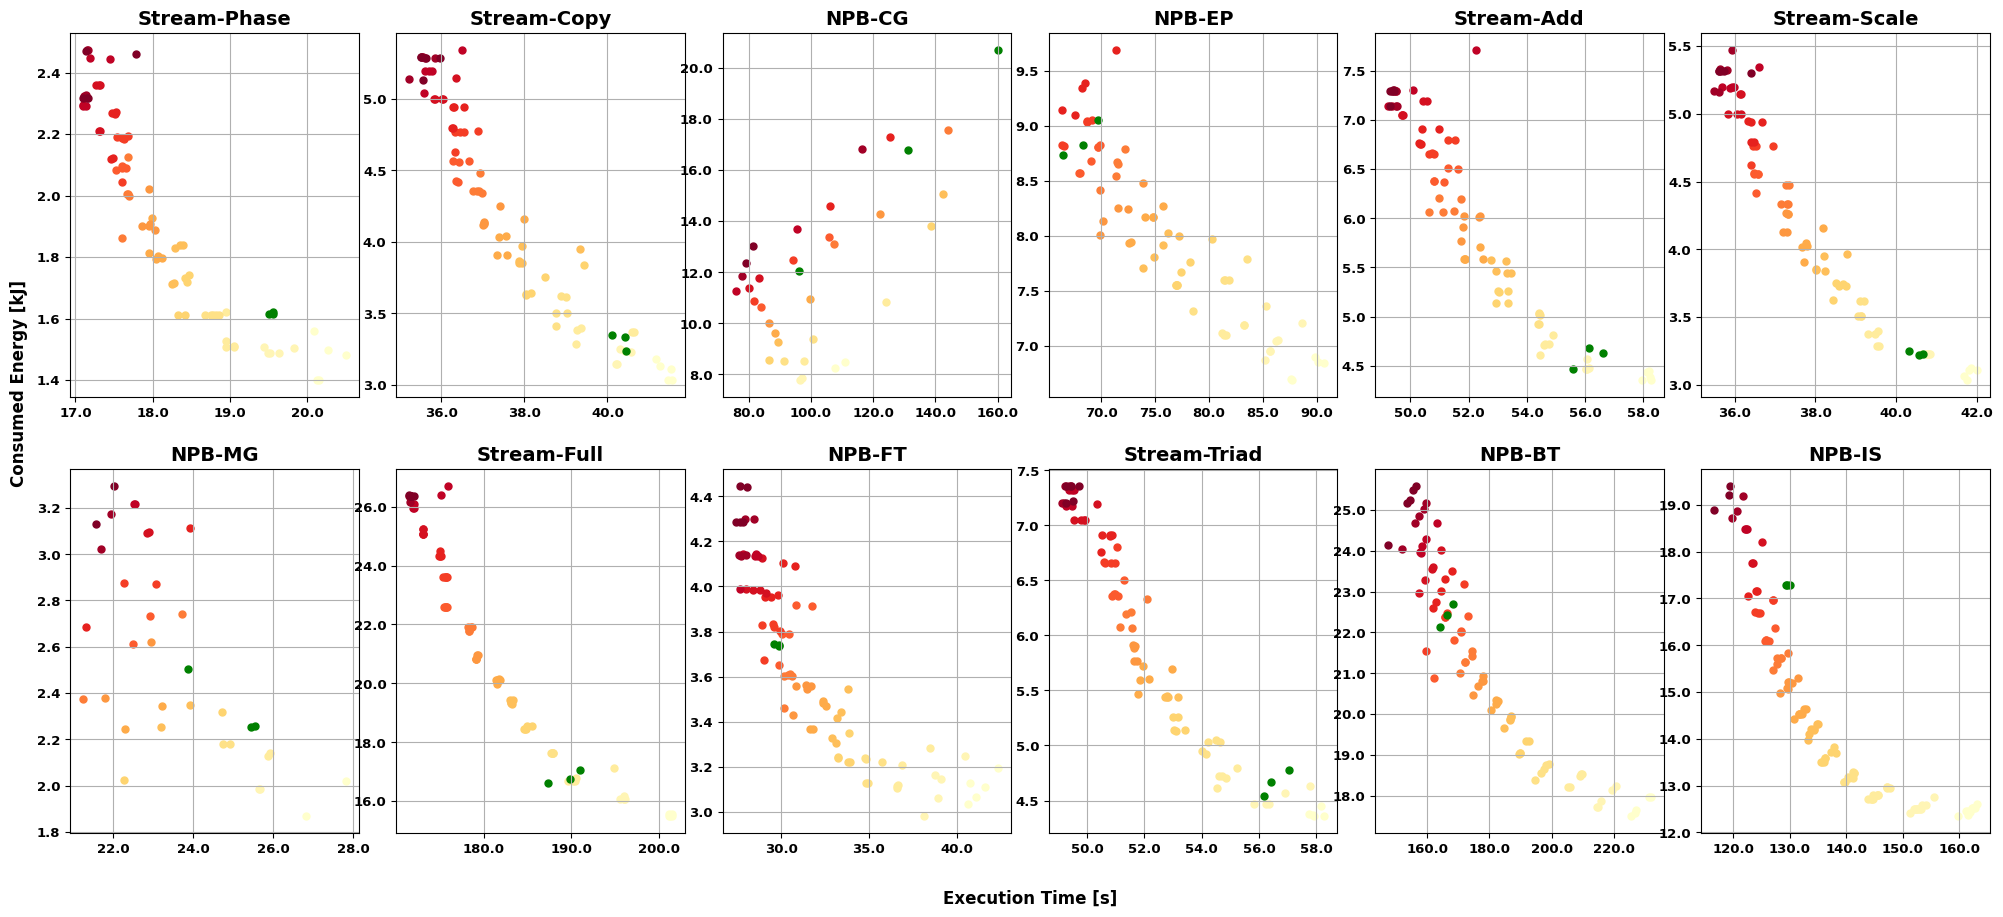

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib import ticker
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import FuncFormatter

# Set up the plot layout with 2 rows and 5 columns
marker_size = 20
num_rows = 2
num_cols = 6
fig, axs = plt.subplots(num_rows, num_cols, figsize=(20, 10))  # Adjusting figsize for 2 rows and 5 columns
plt.rcParams.update({'font.size': 10, "font.weight": "bold", 'axes.labelsize': 'small'})

# Adjusting left margin more aggressively to reduce the space on the left side
plt.subplots_adjust(hspace=0.2, wspace=0.13, top=0.85, bottom=0.05, left=0.02, right=0.98)  # Further reduced left margin to 0.02
fig.text(0.5, -0.02, 'Execution Time [s]', ha='center', fontsize=12)
fig.text(-0.01, 0.5, 'Consumed Energy [kJ]', va='center', rotation='vertical', fontsize=12)

# High contrast colors and normalization for the color map
high_contrast_colors = plt.cm.YlOrRd(np.linspace(0, 1, 16))
sorted_keys = [78.0, 83.0, 89.0, 95.0, 101.0, 107.0, 112.0, 118.0, 124.0, 130.0, 136.0, 141.0, 147.0, 153.0, 159.0, 165.0]
norm = Normalize(vmin=min(sorted_keys), vmax=max(sorted_keys))
smappable = ScalarMappable(cmap='YlOrRd', norm=norm)
smappable.set_array([])

# Mapping the application names as per the table
# app_name_mapping = {
#     'ones-npb-ft': 'NPB-FT',
#     'ones-npb-is': 'NPB-IS',
#     'ones-stream-triad': 'Stream-Triad',
#     'ones-stream-scale': 'Stream-Scale',
#     'ones-stream-copy': 'Stream-Copy',
#     'ones-stream-add': 'Stream-Add',
#     'ones-stream-full': 'Stream-Full',
#     'ones-npb-ep': 'NPB-EP',
#     'phases-stream-full': 'Stream-Phase',
#     'ones-npb-mg': 'NPB-MG'
# }

# For each application in test_results
index = 0
for app in test_results.keys():
    grouped_traces = defaultdict(list)
    max_execution_time = 1  # Set max execution time for normalization
    max_energy_consumption = 1  # Set max energy consumption for normalization

    for trace in test_results[app].keys():
        # Collect traces based on the PCAP value
        grouped_traces[test_results[app][trace]['PCAP'].value.mean()].append(trace)

    for i, PCAP_traces in enumerate(sorted(grouped_traces.keys())):
        # Plot each trace's execution time and energy consumption
        for trace in grouped_traces[PCAP_traces]:
            computed_energy = compute_energy_consump(test_results[app][trace]['power']) / 1000
            # execution_time = test_results[app][trace]['power']['average_power']['elapsed_time'].iloc[-1]
            execution_time = test_results[app][trace]['progress']['progress_sensor']['elapsed_time'].iloc[-1]    
            axs[index // num_cols, index % num_cols].scatter(execution_time / max_execution_time, computed_energy / max_energy_consumption,
                                                              color=high_contrast_colors[i], s=25)

    # Add RL Controller scatter plots
    if app in test_results_control:
        for trace in test_results_control[app].keys():
            computed_energy = compute_energy_consump(test_results_control[app][trace]['power']) / 1000
            # execution_time = test_results_control[app][trace]['power']['average_power']['elapsed_time'].iloc[-1]
            execution_time = test_results_control[app][trace]['progress']['progress_sensor']['elapsed_time'].iloc[-1]
            axs[index // num_cols, index % num_cols].scatter(execution_time / max_execution_time, computed_energy / max_energy_consumption,
                                                              color='green', s=25, label="RL Controller")
    
    # Use the mapping to update the title with the correct name
    axs[index // num_cols, index % num_cols].set_title(app_name_mapping.get(app, app), fontsize=14, loc='center', fontweight='bold')
    axs[index // num_cols, index % num_cols].grid(True)
    axs[index // num_cols, index % num_cols].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))  # Formatting axis
    axs[index // num_cols, index % num_cols].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: round(x, 1)))  # Formatting y-axis
    # Set tick labels bold
    for label in axs[index // num_cols, index % num_cols].get_xticklabels() + axs[index // num_cols, index % num_cols].get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(9.5)
    # Set consistent x-axis range for all subplots
    # axs[index // num_cols, index % num_cols].set_xlim(left=0)  # Set x-axis lower limit to 0
    # axs[index // num_cols, index % num_cols].set_ylim(bottom=0)  # Set y-axis lower limit to 0

    index += 1

# Save the plot to a file
plt.savefig(f'{OUTPUT_DIR}/Energy_vs_time_scatter.pdf', format='pdf', bbox_inches='tight')
plt.show()


ones-npb-cg
ones-npb-bt


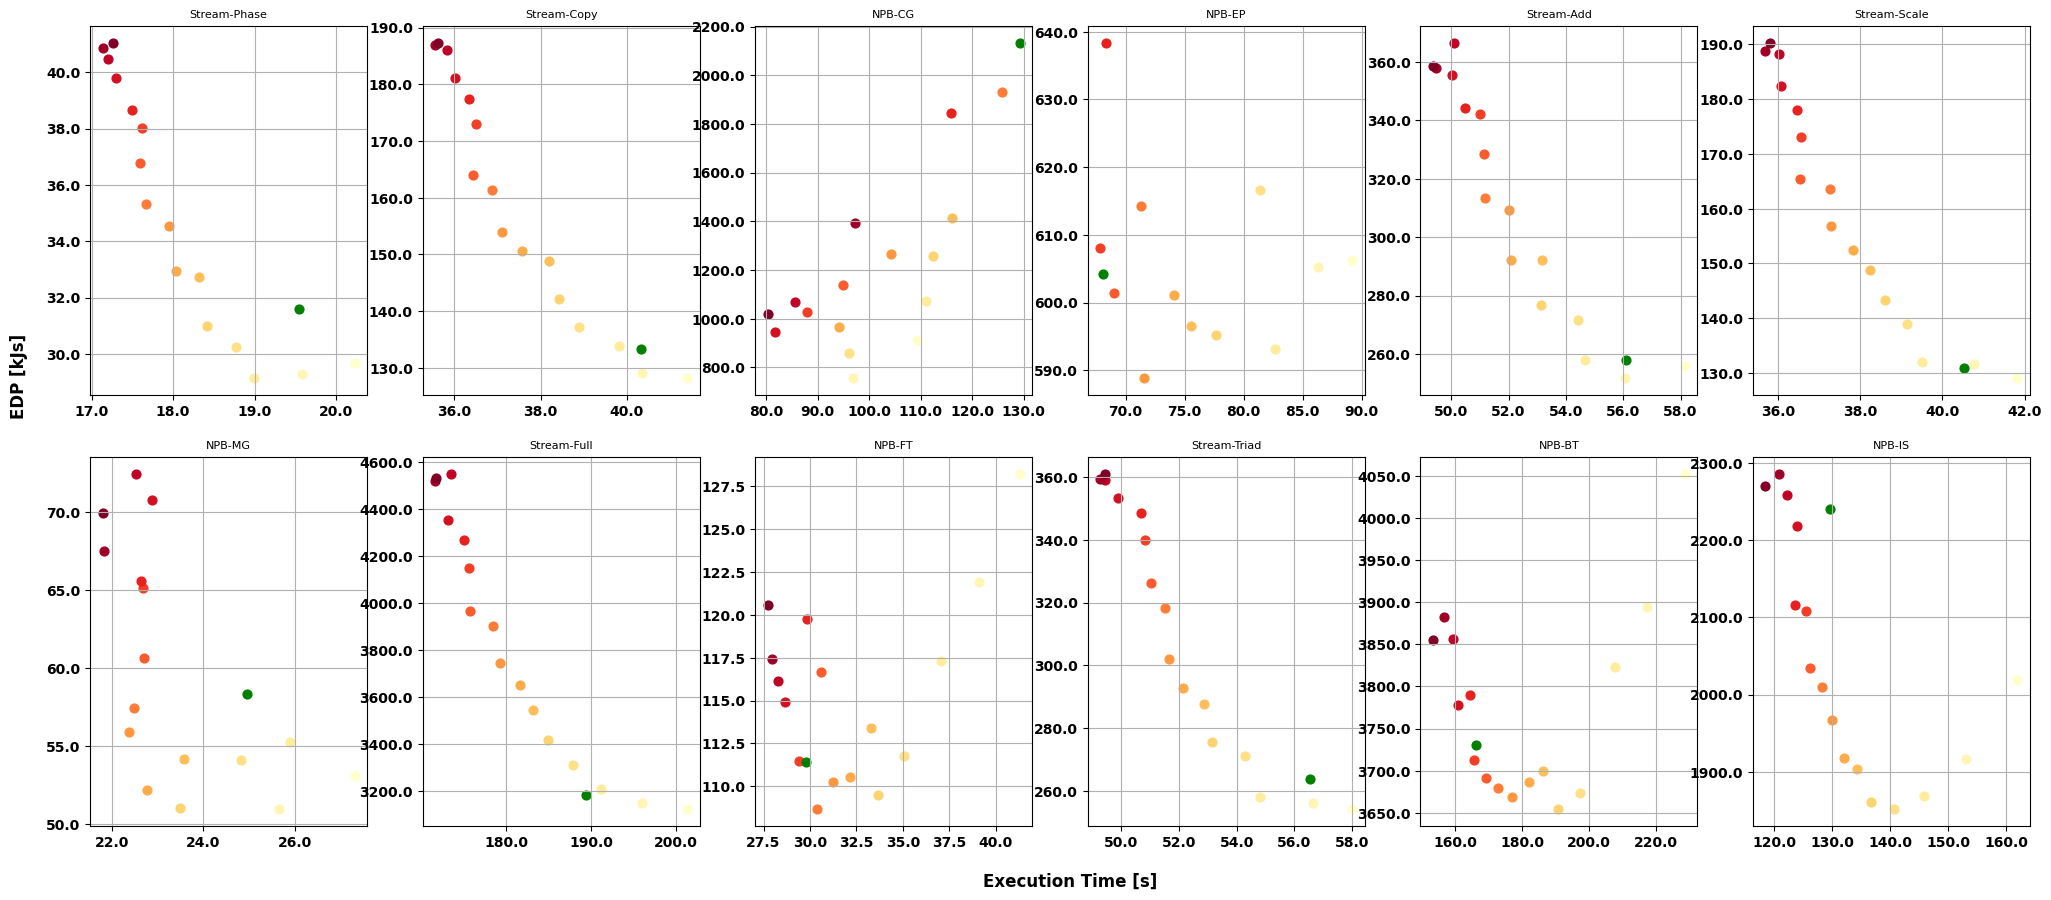

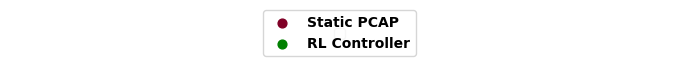

In [ ]:
# marker_size = 20
# num_rows = 2
# num_cols = 5
# fig_edp, axs_edp = plt.subplots(num_rows, num_cols)
# plt.rcParams.update({'font.size': 8, "font.weight": "normal", 'axes.labelsize': 'small'})
# plt.subplots_adjust(hspace=0.15, wspace=0.15, top=0.9, bottom=0.03, left=0.001, right=0.95)  
# fig_edp.text(0.5, -0.04, 'Execution Time / Max Execution Time', ha='center', fontsize=8)
# fig_edp.text(-0.07, 0.5, 'EDP values', va='center', rotation='vertical', fontsize=8)
# index = 0


# Set up the plot layout with 2 rows and 5 columns
marker_size = 40
num_rows = 2
num_cols = 6
fig_edp, axs_edp = plt.subplots(num_rows, num_cols, figsize=(20, 10))  # Adjusting figsize for 2 rows and 5 columns
plt.rcParams.update({'font.size': 10, "font.weight": "bold", 'axes.labelsize': 'small'})

# Adjusting left margin more aggressively to reduce the space on the left side
plt.subplots_adjust(hspace=0.17, wspace=0.2, top=0.85, bottom=0.05, left=0.01, right=0.98)  # Further reduced left margin to 0.02
fig_edp.text(0.5, -0.01, 'Execution Time [s]', ha='center', fontsize=12)
fig_edp.text(-0.03, 0.5, 'EDP [kJs]', va='center', rotation='vertical', fontsize=12)
index = 0

for app in test_results.keys():
    # max_execution_time = max([test_results[app][trace]['power']['average_power']['elapsed_time'].iloc[-1] for trace in test_results[app].keys()])
    # max_energy_consumption = max([compute_energy_consump(test_results[app][trace]['power'])/1000 for trace in test_results[app].keys()])
    max_execution_time = 1
    max_energy_consumption = 1
    max_EDP = max_execution_time*max_energy_consumption
    grouped_traces = defaultdict(list)
    if 'npb-bt' in app or 'npb-cg' in app:
        print(app)
    for trace in test_results[app].keys():
        grouped_traces[test_results[app][trace]['PCAP'].value.mean()].append(trace)
    for i,PCAP_traces in enumerate(sorted(grouped_traces.keys())):     
        computed_energy = np.mean([compute_energy_consump(test_results[app][PCAP_trace]['power']) for PCAP_trace in grouped_traces[PCAP_traces]])/1000 
        # execution_time = np.mean([test_results[app][PCAP_trace]['power']['average_power']['elapsed_time'].iloc[-1] for PCAP_trace in grouped_traces[PCAP_traces]])
        execution_time = np.mean([test_results[app][PCAP_trace]['progress']['progress_sensor']['elapsed_time'].iloc[-1] for PCAP_trace in grouped_traces[PCAP_traces]])
        axs_edp[index//num_cols, index%num_cols].scatter(execution_time/max_execution_time,computed_energy*execution_time/max_EDP, color=high_contrast_colors[i], s=marker_size, label = "Static PCAP")

            
    axs_edp[index//num_cols, index%num_cols].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))  # Change format as needed
    axs_edp[index//num_cols, index%num_cols].set_title(app_name_mapping.get(app, app), fontsize=8, loc='center')
    axs_edp[index//num_cols, index%num_cols].grid(True)

    # index += 1


# index = 0
# for app in test_results_control.keys():
    # for trace in test_results_control[app].keys():
    computed_energy = np.mean([compute_energy_consump(test_results_control[app][trace]['power'])/1000 for trace in test_results_control[app].keys()])
    # execution_time = np.mean([test_results_control[app][trace]['power']['average_power']['elapsed_time'].iloc[-1] for trace in test_results_control[app].keys()])
    execution_time = np.mean([test_results_control[app][trace]['progress']['progress_sensor']['elapsed_time'].iloc[-1] for trace in test_results_control[app].keys()])
    axs_edp[index//num_cols, index%num_cols].scatter(execution_time/max_execution_time, computed_energy*execution_time/max_EDP, color='green', s=marker_size, label = "RL Controller")
    axs_edp[index//num_cols, index%num_cols].yaxis.set_major_formatter(FuncFormatter(lambda x, _: round(x, 1)))    
    axs_edp[index//num_cols, index%num_cols].xaxis.set_major_formatter(FuncFormatter(lambda x, _: round(x, 1)))
    # axs_edp[index//num_cols, index%num_cols].text(test_results_control[app][trace]['power']['average_power']['elapsed_time'].iloc[-1], computed_energy*test_results_control[app][trace]['power']['average_power']['elapsed_time'].iloc[-1],f'{trace}')
    index += 1



handles, labels = axs_edp[0,0].get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))     

for i in range(num_rows):
    for j in range(num_cols):
        if j > 0:
            axs[i, j].set_yticks(np.linspace(axs[i,j].get_ylim()[0], axs[i,j].get_ylim()[1], 5))
            axs[i, j].set_yticklabels([])
        else:
            axs[i,j].set_yticks(np.linspace(axs[i,j].get_ylim()[0], axs[i,j].get_ylim()[1], 5))
        if i == 0:
            axs[i, j].set_xticklabels([])
plt.savefig(f'{OUTPUT_DIR}/comparison_EDP_average.pdf', format='pdf', bbox_inches='tight')  # Save the figure

fig_leg, ax_leg = plt.subplots(figsize=(8.5,0.3))

ax_leg.legend(loc='center')

ax_leg.axis('off')
fig_leg.legend(unique_labels.values(), unique_labels.keys(), loc='center', ncol=1)

plt.savefig(f'{OUTPUT_DIR}/legend_only.pdf', format='pdf', bbox_inches='tight')
plt.show()

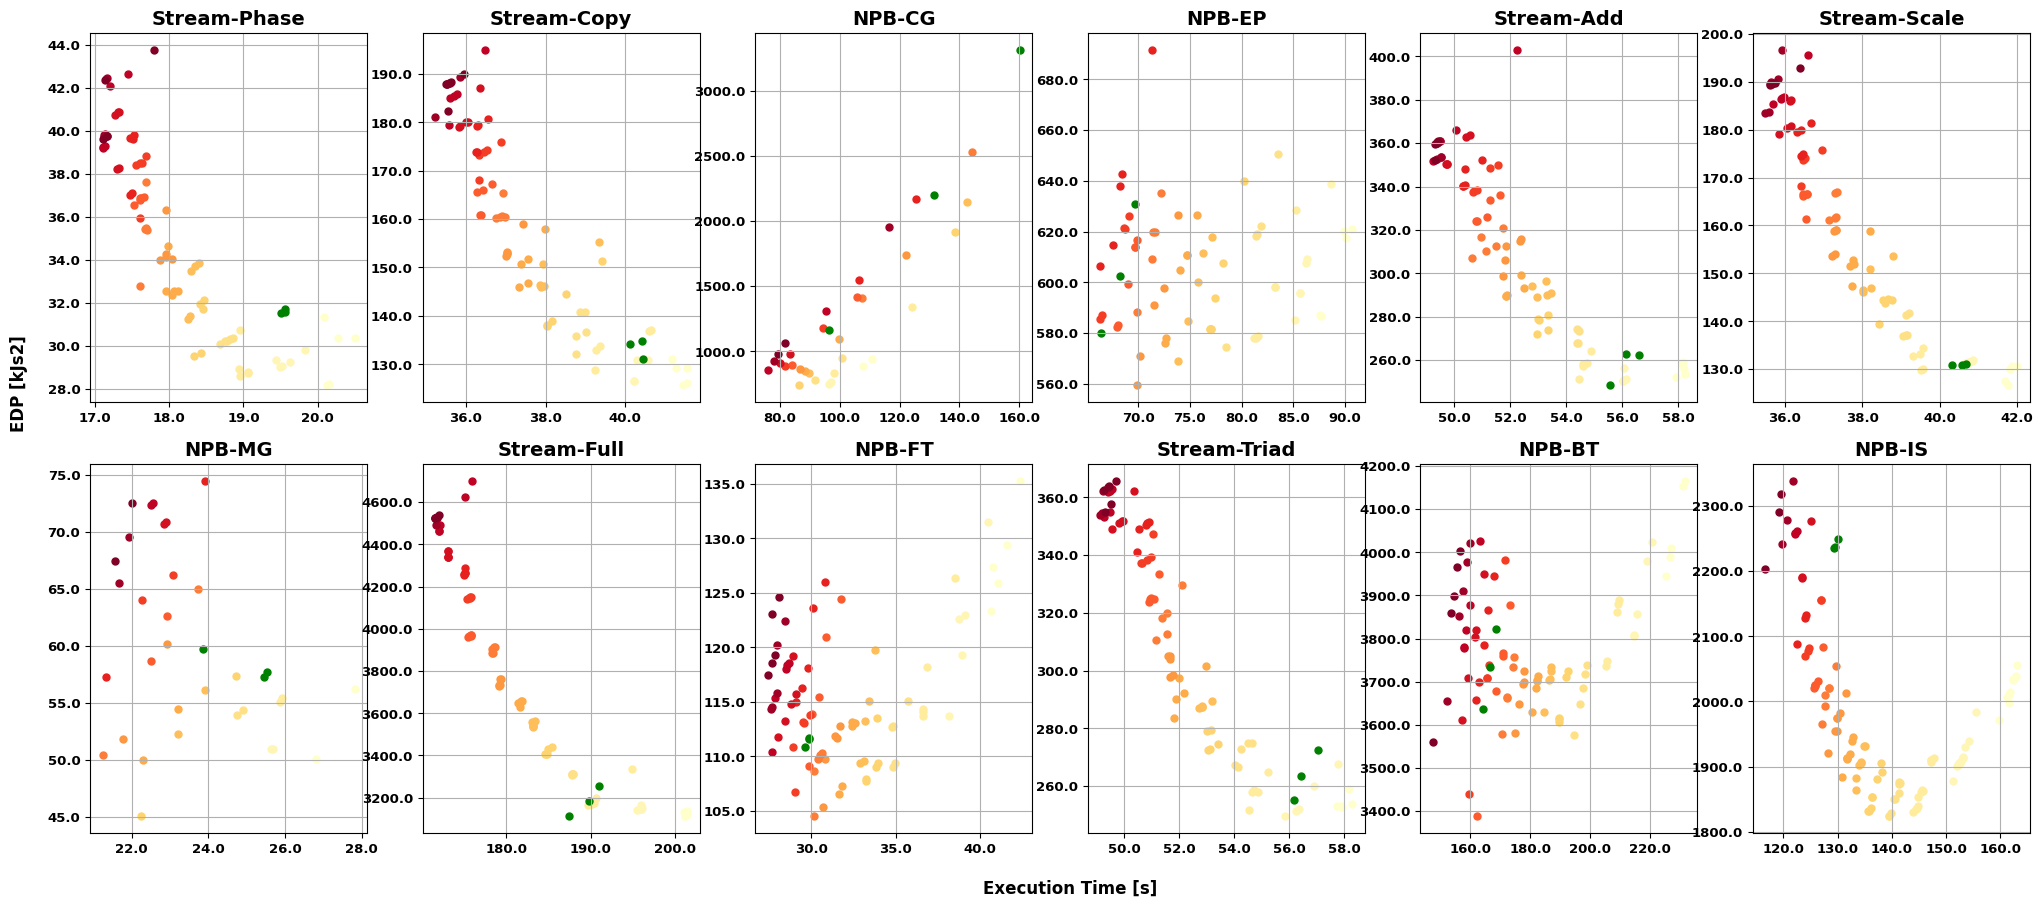

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib import ticker
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import FuncFormatter

# Set up the plot layout with 2 rows and 5 columns
marker_size = 20
num_rows = 2
num_cols = 6
fig, axs = plt.subplots(num_rows, num_cols, figsize=(20, 10))  # Adjusting figsize for 2 rows and 5 columns
plt.rcParams.update({'font.size': 10, "font.weight": "bold", 'axes.labelsize': 'small'})

# Adjusting left margin more aggressively to reduce the space on the left side
plt.subplots_adjust(hspace=0.17, wspace=0.2, top=0.85, bottom=0.05, left=0.01, right=0.98)  # Further reduced left margin to 0.02
fig.text(0.5, -0.01, 'Execution Time [s]', ha='center', fontsize=12)
fig.text(-0.03, 0.5, 'EDP [kJs2]', va='center', rotation='vertical', fontsize=12)

# High contrast colors and normalization for the color map
high_contrast_colors = plt.cm.YlOrRd(np.linspace(0, 1, 16))
sorted_keys = [78.0, 83.0, 89.0, 95.0, 101.0, 107.0, 112.0, 118.0, 124.0, 130.0, 136.0, 141.0, 147.0, 153.0, 159.0, 165.0]
norm = Normalize(vmin=min(sorted_keys), vmax=max(sorted_keys))
smappable = ScalarMappable(cmap='YlOrRd', norm=norm)
smappable.set_array([])

# Mapping the application names as per the table
# app_name_mapping = {
#     'ones-npb-ft': 'NPB-FT',
#     'ones-npb-is': 'NPB-IS',
#     'ones-stream-triad': 'Stream-Triad',
#     'ones-stream-scale': 'Stream-Scale',
#     'ones-stream-copy': 'Stream-Copy',
#     'ones-stream-add': 'Stream-Add',
#     'ones-stream-full': 'Stream-Full',
#     'ones-npb-ep': 'NPB-EP',
#     'phases-stream-full': 'Stream-Phase',
#     'ones-npb-mg': 'NPB-MG'
# }

# For each application in test_results
index = 0
for app in test_results.keys():
    grouped_traces = defaultdict(list)
    max_execution_time = 1  # Set max execution time for normalization
    max_energy_consumption = 1  # Set max energy consumption for normalization

    for trace in test_results[app].keys():
        # Collect traces based on the PCAP value
        grouped_traces[test_results[app][trace]['PCAP'].value.mean()].append(trace)

    for i, PCAP_traces in enumerate(sorted(grouped_traces.keys())):
        # Plot each trace's execution time and energy consumption
        for trace in grouped_traces[PCAP_traces]:
            computed_energy = compute_energy_consump(test_results[app][trace]['power']) / 1000
            execution_time = test_results[app][trace]['progress']['progress_sensor']['elapsed_time'].iloc[-1]
            axs[index // num_cols, index % num_cols].scatter(execution_time , computed_energy*execution_time,
                                                              color=high_contrast_colors[i], s=25)

    # Add RL Controller scatter plots
    if app in test_results_control:
        for trace in test_results_control[app].keys():
            computed_energy = compute_energy_consump(test_results_control[app][trace]['power']) / 1000
            execution_time = test_results_control[app][trace]['progress']['progress_sensor']['elapsed_time'].iloc[-1]
            axs[index // num_cols, index % num_cols].scatter(execution_time , computed_energy*execution_time ,
                                                              color='green', s=25, label="RL Controller")
    
    # Use the mapping to update the title with the correct name
    axs[index // num_cols, index % num_cols].set_title(app_name_mapping.get(app, app), fontsize=14, loc='center', fontweight='bold')
    axs[index // num_cols, index % num_cols].grid(True)
    axs[index // num_cols, index % num_cols].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))  # Formatting axis
    axs[index // num_cols, index % num_cols].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: round(x, 1)))  # Formatting y-axis
    # Set tick labels bold
    for label in axs[index // num_cols, index % num_cols].get_xticklabels() + axs[index // num_cols, index % num_cols].get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(9.5)
    # Set consistent x-axis range for all subplots
    # axs[index // num_cols, index % num_cols].set_xlim(left=0)  # Set x-axis lower limit to 0
    # axs[index // num_cols, index % num_cols].set_ylim(bottom=0)  # Set y-axis lower limit to 0
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))  # Always use scientific notation
    ax.yaxis.set_major_formatter(formatter)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    # Optionally, set font size and weight for y-tick labels
    for label in ax.get_yticklabels():
        label.set_fontsize(10)
        label.set_fontweight('bold')
    index += 1

# Save the plot to a file
plt.savefig(f'{OUTPUT_DIR}/comparison_EDP_scatter.pdf', format='pdf', bbox_inches='tight')
plt.show()


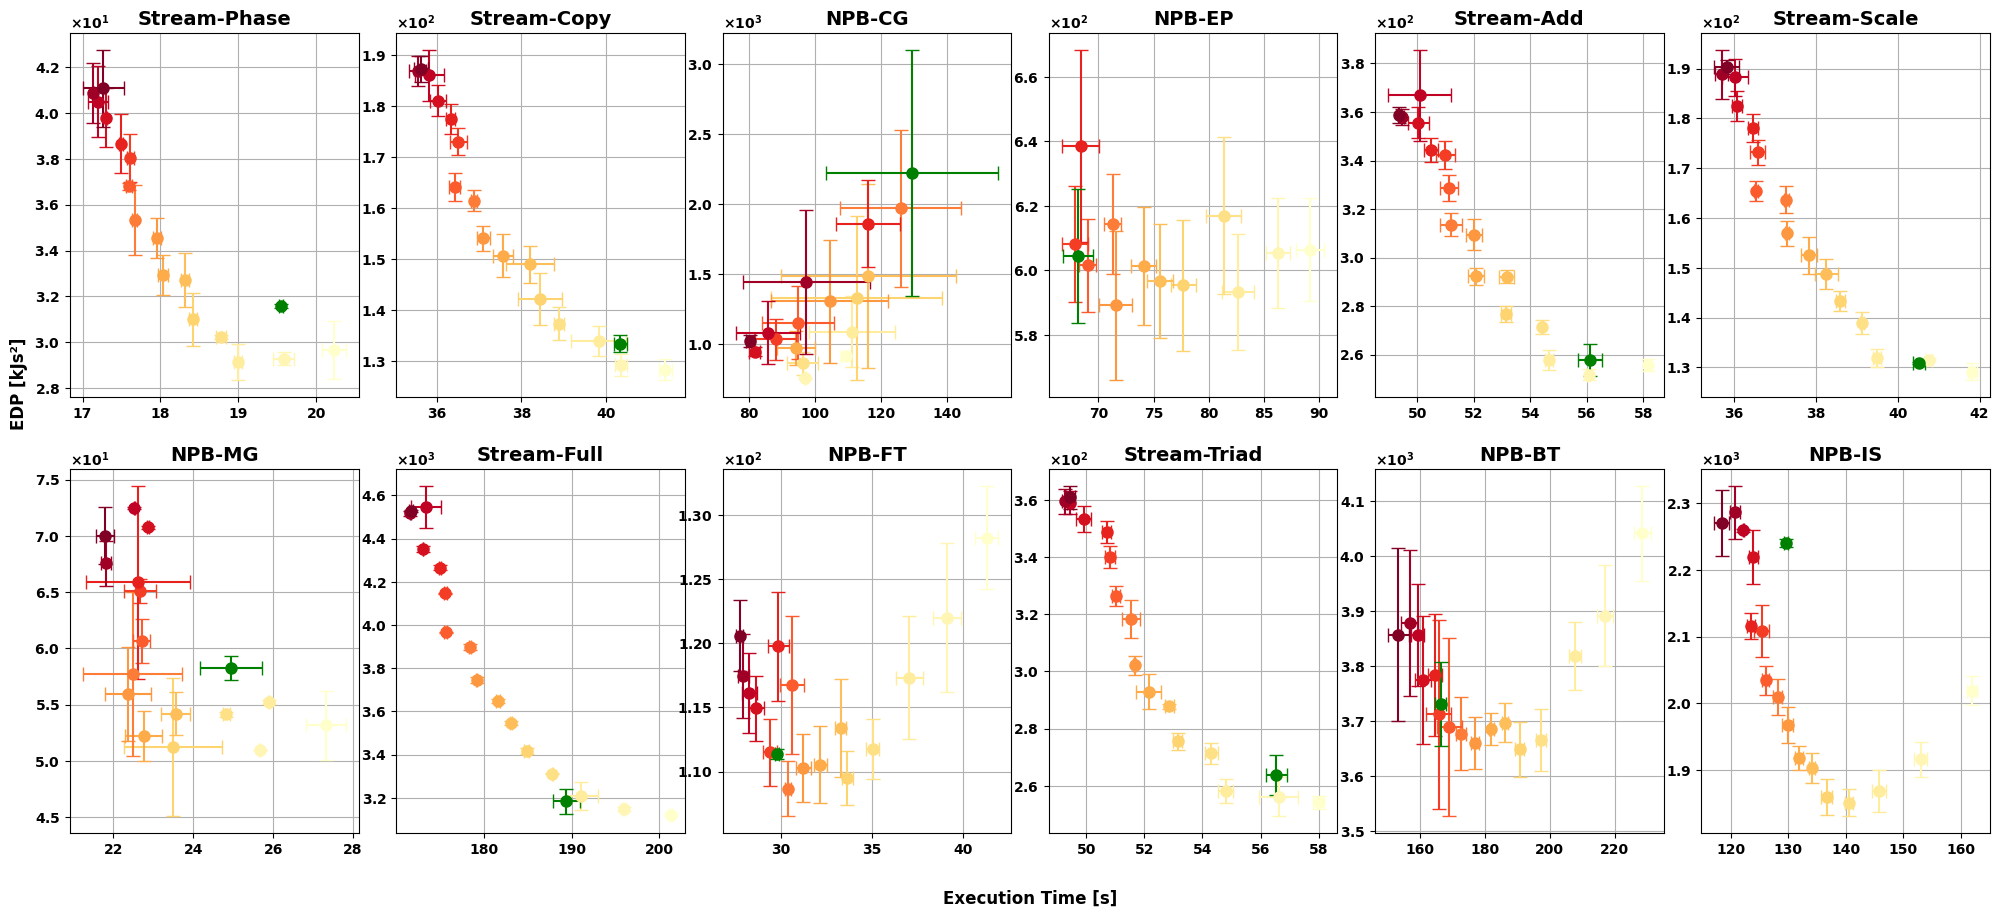

In [ ]:
marker_size = 40
num_rows = 2
num_cols = 6
fig, axs = plt.subplots(num_rows, num_cols, figsize=(20, 10))
plt.rcParams.update({'font.size': 10, "font.weight": "bold", 'axes.labelsize': 'small'})

plt.subplots_adjust(hspace=0.2, wspace=0.13, top=0.85, bottom=0.05, left=0.02, right=0.98)
fig.text(0.5, -0.02, 'Execution Time [s]', ha='center', fontsize=12)
fig.text(-0.01, 0.5, 'EDP [kJs²]', va='center', rotation='vertical', fontsize=12)
index = 0

high_contrast_colors = plt.cm.YlOrRd(np.linspace(0, 1, 16))
sorted_keys = [78.0, 83.0, 89.0, 95.0, 101.0, 107.0, 112.0, 118.0, 124.0, 130.0, 136.0, 141.0, 147.0, 153.0, 159.0, 165.0]

from collections import defaultdict

for app in test_results.keys():
    grouped_traces = defaultdict(list)
    for trace in test_results[app].keys():
        grouped_traces[test_results[app][trace]['PCAP'].value.mean()].append(trace)

    for i, PCAP_traces in enumerate(sorted(grouped_traces.keys())):
        edp_list = []
        exec_time_list = []
        for PCAP_trace in grouped_traces[PCAP_traces]:
            start_time = test_results[app][PCAP_trace]['progress']['progress_sensor'].time.iloc[0]
            end_time = test_results[app][PCAP_trace]['progress']['progress_sensor'].time.iloc[-1]
            energy = compute_energy_consump(test_results[app][PCAP_trace]['power'], start_time=start_time, end_time=end_time) / 1000
            exec_time = test_results[app][PCAP_trace]['progress']['progress_sensor']['elapsed_time'].iloc[-1]
            edp = energy * exec_time
            edp_list.append(edp)
            exec_time_list.append(exec_time)
        # Calculate mean and std for this group
        edp_mean = np.mean(edp_list)
        edp_std = np.std(edp_list)
        exec_time_mean = np.mean(exec_time_list)
        exec_time_std = np.std(exec_time_list)
        color = high_contrast_colors[i % len(high_contrast_colors)]
        ax = axs[index//num_cols, index%num_cols]
        ax.errorbar(
            exec_time_mean, edp_mean,
            xerr=exec_time_std, yerr=edp_std,
            fmt='o', color=color, markersize=marker_size/5, capsize=5, zorder=5
        )
    ax.set_title(app_name_mapping.get(app, app), fontsize=14, loc='center', fontweight='bold')
    ax.grid(True)

    # Add RL Controller (control) mean and std as error bars for EDP
    edp_control = [
        (compute_energy_consump(test_results_control[app][trace]['power']) / 1000) *
        test_results_control[app][trace]['progress']['progress_sensor']['elapsed_time'].iloc[-1]
        for trace in test_results_control[app].keys()
    ]
    exec_time_control = [
        test_results_control[app][trace]['progress']['progress_sensor']['elapsed_time'].iloc[-1]
        for trace in test_results_control[app].keys()
    ]
    edp_mean_control = np.mean(edp_control)
    edp_std_control = np.std(edp_control)
    exec_time_mean_control = np.mean(exec_time_control)
    exec_time_std_control = np.std(exec_time_control)

    ax.errorbar(
        exec_time_mean_control, edp_mean_control,
        xerr=exec_time_std_control, yerr=edp_std_control,
        fmt='o', color='green', markersize=marker_size/5, label="RL Controller", capsize=5, zorder=5
    )
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))  # Always use scientific notation
    ax.yaxis.set_major_formatter(formatter)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    # Optionally, set font size and weight for y-tick labels
    for label in ax.get_yticklabels():
        label.set_fontsize(10)
        label.set_fontweight('bold')
    index += 1

fig.savefig(f'{OUTPUT_DIR}/comparison_EDP_mean_std_dev.pdf', format='pdf', bbox_inches='tight')

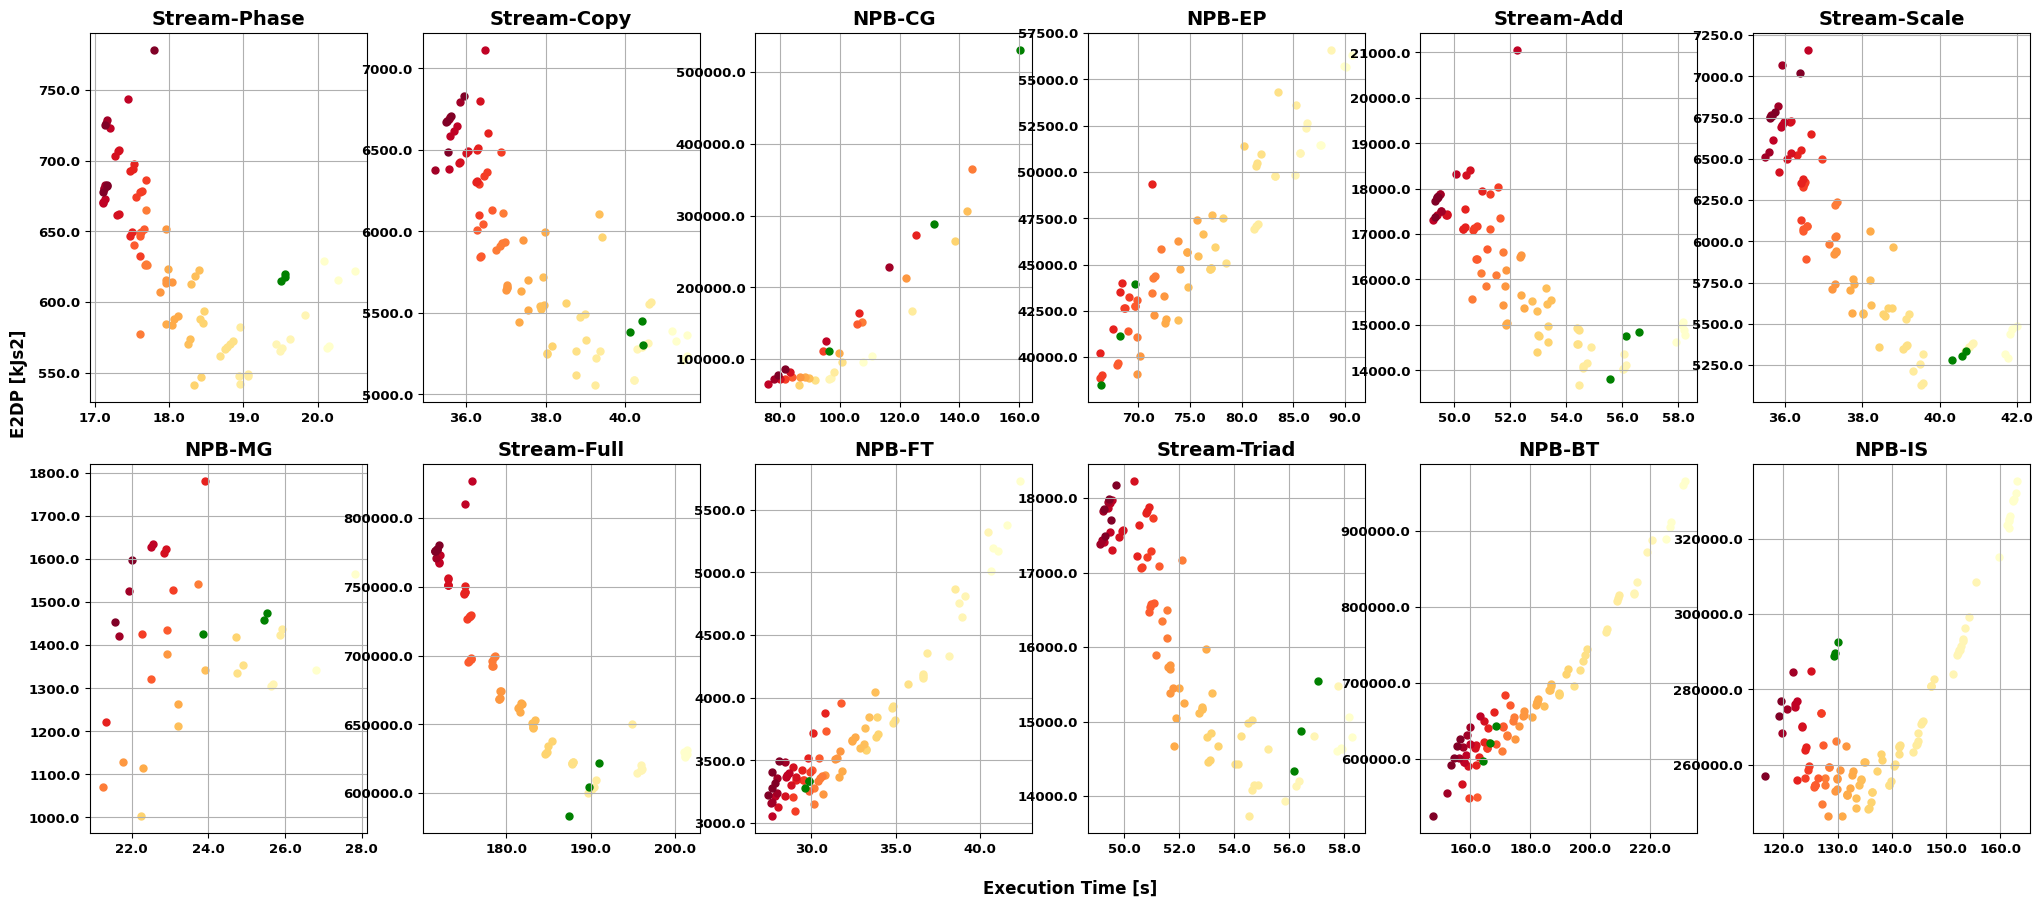

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib import ticker
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import FuncFormatter

# Set up the plot layout with 2 rows and 5 columns
marker_size = 20
num_rows = 2
num_cols = 6
fig, axs = plt.subplots(num_rows, num_cols, figsize=(20, 10))  # Adjusting figsize for 2 rows and 5 columns
plt.rcParams.update({'font.size': 10, "font.weight": "bold", 'axes.labelsize': 'small'})

# Adjusting left margin more aggressively to reduce the space on the left side
plt.subplots_adjust(hspace=0.17, wspace=0.2, top=0.85, bottom=0.05, left=0.01, right=0.98)  # Further reduced left margin to 0.02
fig.text(0.5, -0.01, 'Execution Time [s]', ha='center', fontsize=12)
fig.text(-0.03, 0.5, 'E2DP [kJs2]', va='center', rotation='vertical', fontsize=12)

# High contrast colors and normalization for the color map
high_contrast_colors = plt.cm.YlOrRd(np.linspace(0, 1, 16))
sorted_keys = [78.0, 83.0, 89.0, 95.0, 101.0, 107.0, 112.0, 118.0, 124.0, 130.0, 136.0, 141.0, 147.0, 153.0, 159.0, 165.0]
norm = Normalize(vmin=min(sorted_keys), vmax=max(sorted_keys))
smappable = ScalarMappable(cmap='YlOrRd', norm=norm)
smappable.set_array([])

# Mapping the application names as per the table
# app_name_mapping = {
#     'ones-npb-ft': 'NPB-FT',
#     'ones-npb-is': 'NPB-IS',
#     'ones-stream-triad': 'Stream-Triad',
#     'ones-stream-scale': 'Stream-Scale',
#     'ones-stream-copy': 'Stream-Copy',
#     'ones-stream-add': 'Stream-Add',
#     'ones-stream-full': 'Stream-Full',
#     'ones-npb-ep': 'NPB-EP',
#     'phases-stream-full': 'Stream-Phase',
#     'ones-npb-mg': 'NPB-MG'
# }

# For each application in test_results
index = 0
for app in test_results.keys():
    grouped_traces = defaultdict(list)
    max_execution_time = 1  # Set max execution time for normalization
    max_energy_consumption = 1  # Set max energy consumption for normalization

    for trace in test_results[app].keys():
        # Collect traces based on the PCAP value
        grouped_traces[test_results[app][trace]['PCAP'].value.mean()].append(trace)

    for i, PCAP_traces in enumerate(sorted(grouped_traces.keys())):
        # Plot each trace's execution time and energy consumption
        for trace in grouped_traces[PCAP_traces]:
            computed_energy = compute_energy_consump(test_results[app][trace]['power']) / 1000
            execution_time = test_results[app][trace]['progress']['progress_sensor']['elapsed_time'].iloc[-1]
            axs[index // num_cols, index % num_cols].scatter(execution_time , computed_energy*execution_time**2,
                                                              color=high_contrast_colors[i], s=25)

    # Add RL Controller scatter plots
    if app in test_results_control:
        for trace in test_results_control[app].keys():
            computed_energy = compute_energy_consump(test_results_control[app][trace]['power']) / 1000
            execution_time = test_results_control[app][trace]['progress']['progress_sensor']['elapsed_time'].iloc[-1]
            axs[index // num_cols, index % num_cols].scatter(execution_time , computed_energy*execution_time**2 ,
                                                              color='green', s=25, label="RL Controller")
    
    # Use the mapping to update the title with the correct name
    axs[index // num_cols, index % num_cols].set_title(app_name_mapping.get(app, app), fontsize=14, loc='center', fontweight='bold')
    axs[index // num_cols, index % num_cols].grid(True)
    axs[index // num_cols, index % num_cols].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))  # Formatting axis
    axs[index // num_cols, index % num_cols].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: round(x, 1)))  # Formatting y-axis
    # Set tick labels bold
    for label in axs[index // num_cols, index % num_cols].get_xticklabels() + axs[index // num_cols, index % num_cols].get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(9.5)
    # Set consistent x-axis range for all subplots
    # axs[index // num_cols, index % num_cols].set_xlim(left=0)  # Set x-axis lower limit to 0
    # axs[index // num_cols, index % num_cols].set_ylim(bottom=0)  # Set y-axis lower limit to 0
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))  # Always use scientific notation
    ax.yaxis.set_major_formatter(formatter)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    # Optionally, set font size and weight for y-tick labels
    for label in ax.get_yticklabels():
        label.set_fontsize(10)
        label.set_fontweight('bold')
    index += 1

# Save the plot to a file
plt.savefig(f'{OUTPUT_DIR}/comparison_ED2P_scatter.pdf', format='pdf', bbox_inches='tight')
plt.show()


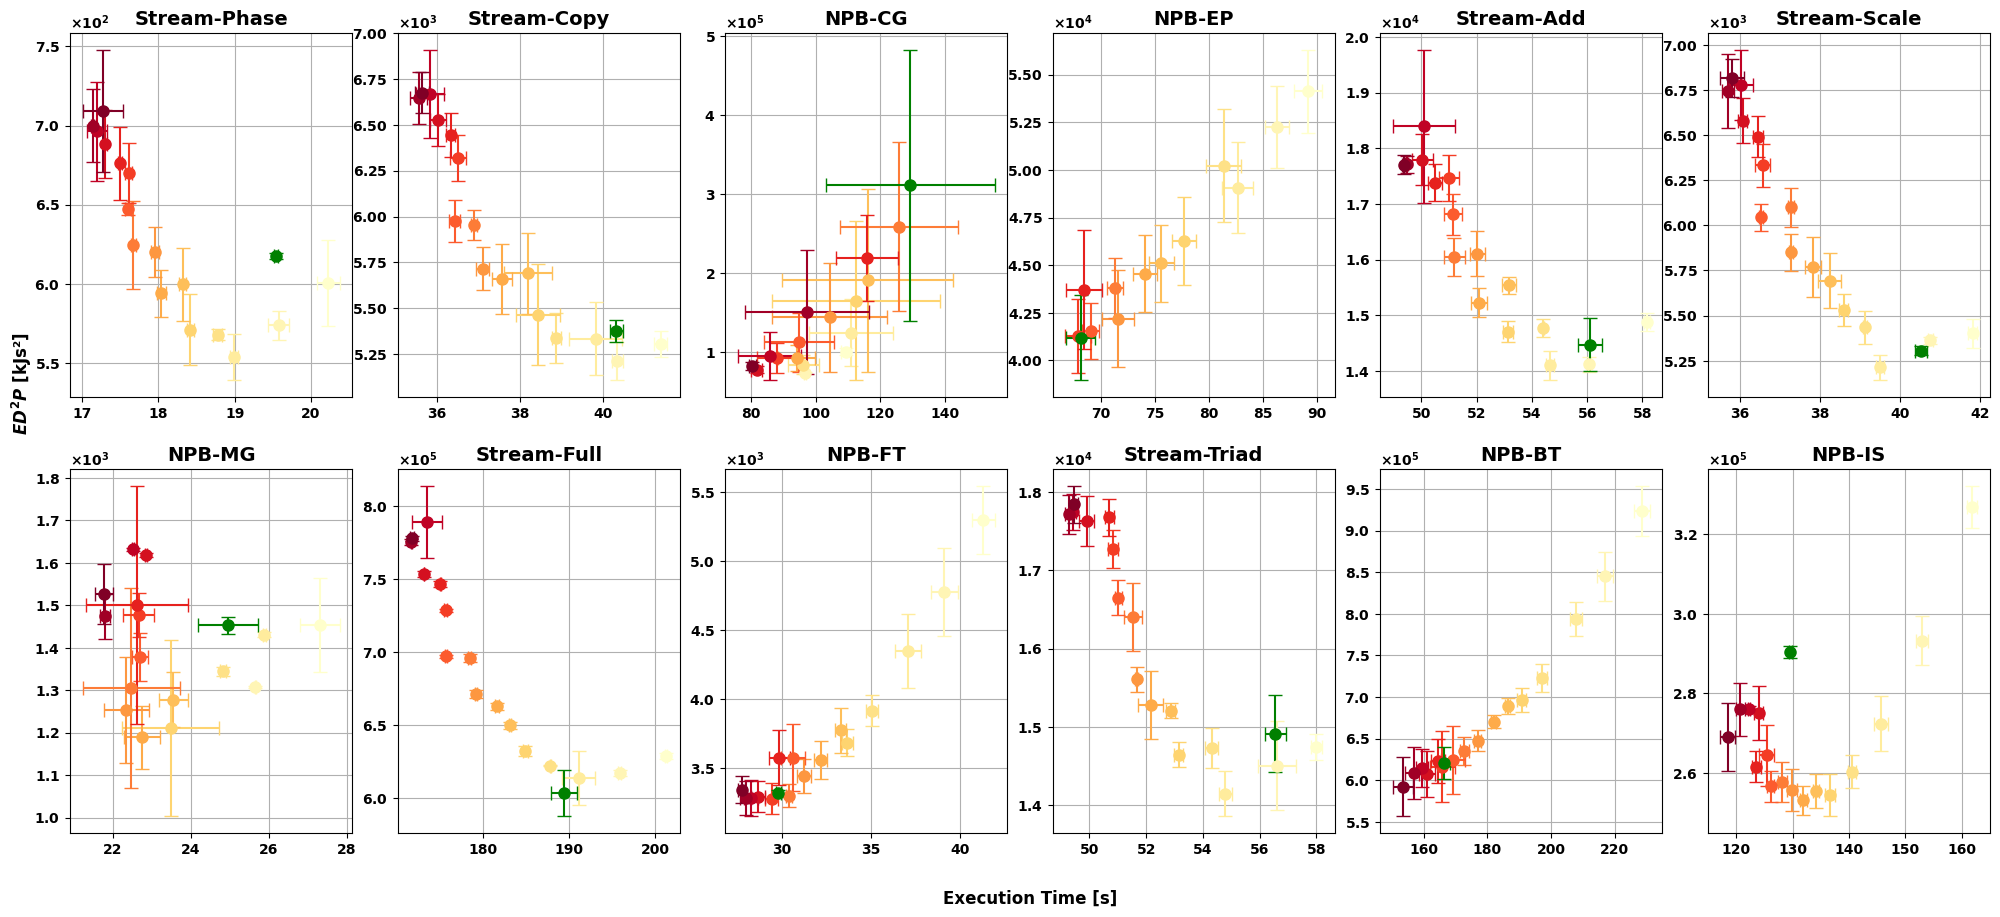

In [ ]:
import matplotlib.ticker as mticker

# app_name_mapping = {
#     'ones-npb-ft': 'NPB-FT',
#     'ones-npb-is': 'NPB-IS',
#     'ones-stream-triad': 'Stream-Triad',
#     'ones-stream-scale': 'Stream-Scale',
#     'ones-stream-copy': 'Stream-Copy',
#     'ones-stream-add': 'Stream-Add',
#     'ones-stream-full': 'Stream-Full',
#     'ones-npb-ep': 'NPB-EP',
#     'ones-stream-phase': 'Stream-Phase',
#     'ones-npb-mg': 'NPB-MG'
# }
marker_size = 40
num_rows = 2
num_cols = 6
fig, axs = plt.subplots(num_rows, num_cols, figsize=(20, 10))
plt.rcParams.update({'font.size': 10, "font.weight": "bold", 'axes.labelsize': 'small'})

plt.subplots_adjust(hspace=0.2, wspace=0.16, top=0.85, bottom=0.05, left=0.02, right=0.98)
fig.text(0.5, -0.02, 'Execution Time [s]', ha='center', fontsize=12)
fig.text(-0.01, 0.5, r'$ED^2P$ [kJs²]', va='center', rotation='vertical', fontsize=12)
index = 0

high_contrast_colors = plt.cm.YlOrRd(np.linspace(0, 1, 16))
sorted_keys = [78.0, 83.0, 89.0, 95.0, 101.0, 107.0, 112.0, 118.0, 124.0, 130.0, 136.0, 141.0, 147.0, 153.0, 159.0, 165.0]

from collections import defaultdict

for app in test_results.keys():
    grouped_traces = defaultdict(list)
    for trace in test_results[app].keys():
        grouped_traces[test_results[app][trace]['PCAP'].value.mean()].append(trace)

    for i, PCAP_traces in enumerate(sorted(grouped_traces.keys())):
        ed2p_list = []
        exec_time_list = []
        for PCAP_trace in grouped_traces[PCAP_traces]:
            start_time = test_results[app][PCAP_trace]['progress']['progress_sensor'].time.iloc[0]
            end_time = test_results[app][PCAP_trace]['progress']['progress_sensor'].time.iloc[-1]
            energy = compute_energy_consump(test_results[app][PCAP_trace]['power'], start_time=start_time, end_time=end_time) / 1000
            exec_time = test_results[app][PCAP_trace]['progress']['progress_sensor']['elapsed_time'].iloc[-1]
            ed2p = energy * exec_time**2
            ed2p_list.append(ed2p)
            exec_time_list.append(exec_time)
        # Calculate mean and std for this group
        ed2p_mean = np.mean(ed2p_list)
        ed2p_std = np.std(ed2p_list)
        exec_time_mean = np.mean(exec_time_list)
        exec_time_std = np.std(exec_time_list)
        color = high_contrast_colors[i % len(high_contrast_colors)]
        ax = axs[index//num_cols, index%num_cols]
        ax.errorbar(
            exec_time_mean, ed2p_mean,
            xerr=exec_time_std, yerr=ed2p_std,
            fmt='o', color=color, markersize=marker_size/5, capsize=5, zorder=5
        )
    ax.set_title(app_name_mapping.get(app, app), fontsize=14, loc='center', fontweight='bold')
    ax.grid(True)

    # Add RL Controller (control) mean and std as error bars for EDP
    ed2p_control = [
        (compute_energy_consump(test_results_control[app][trace]['power']) / 1000) *
        test_results_control[app][trace]['progress']['progress_sensor']['elapsed_time'].iloc[-1]**2
        for trace in test_results_control[app].keys()
    ]
    exec_time_control = [
        test_results_control[app][trace]['progress']['progress_sensor']['elapsed_time'].iloc[-1]
        for trace in test_results_control[app].keys()
    ]
    ed2p_mean_control = np.mean(ed2p_control)
    ed2p_std_control = np.std(ed2p_control)
    exec_time_mean_control = np.mean(exec_time_control)
    exec_time_std_control = np.std(exec_time_control)

    ax.errorbar(
        exec_time_mean_control, ed2p_mean_control,
        xerr=exec_time_std_control, yerr=ed2p_std_control,
        fmt='o', color='green', markersize=marker_size/5, label="RL Controller", capsize=5, zorder=5
    )
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))  # Always use scientific notation
    ax.yaxis.set_major_formatter(formatter)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    # Optionally, set font size and weight for y-tick labels
    for label in ax.get_yticklabels():
        label.set_fontsize(10)
        label.set_fontweight('bold')
    index += 1

fig.savefig(f'{OUTPUT_DIR}/comparison_ED2P_mean_std_dev.pdf', format='pdf', bbox_inches='tight')

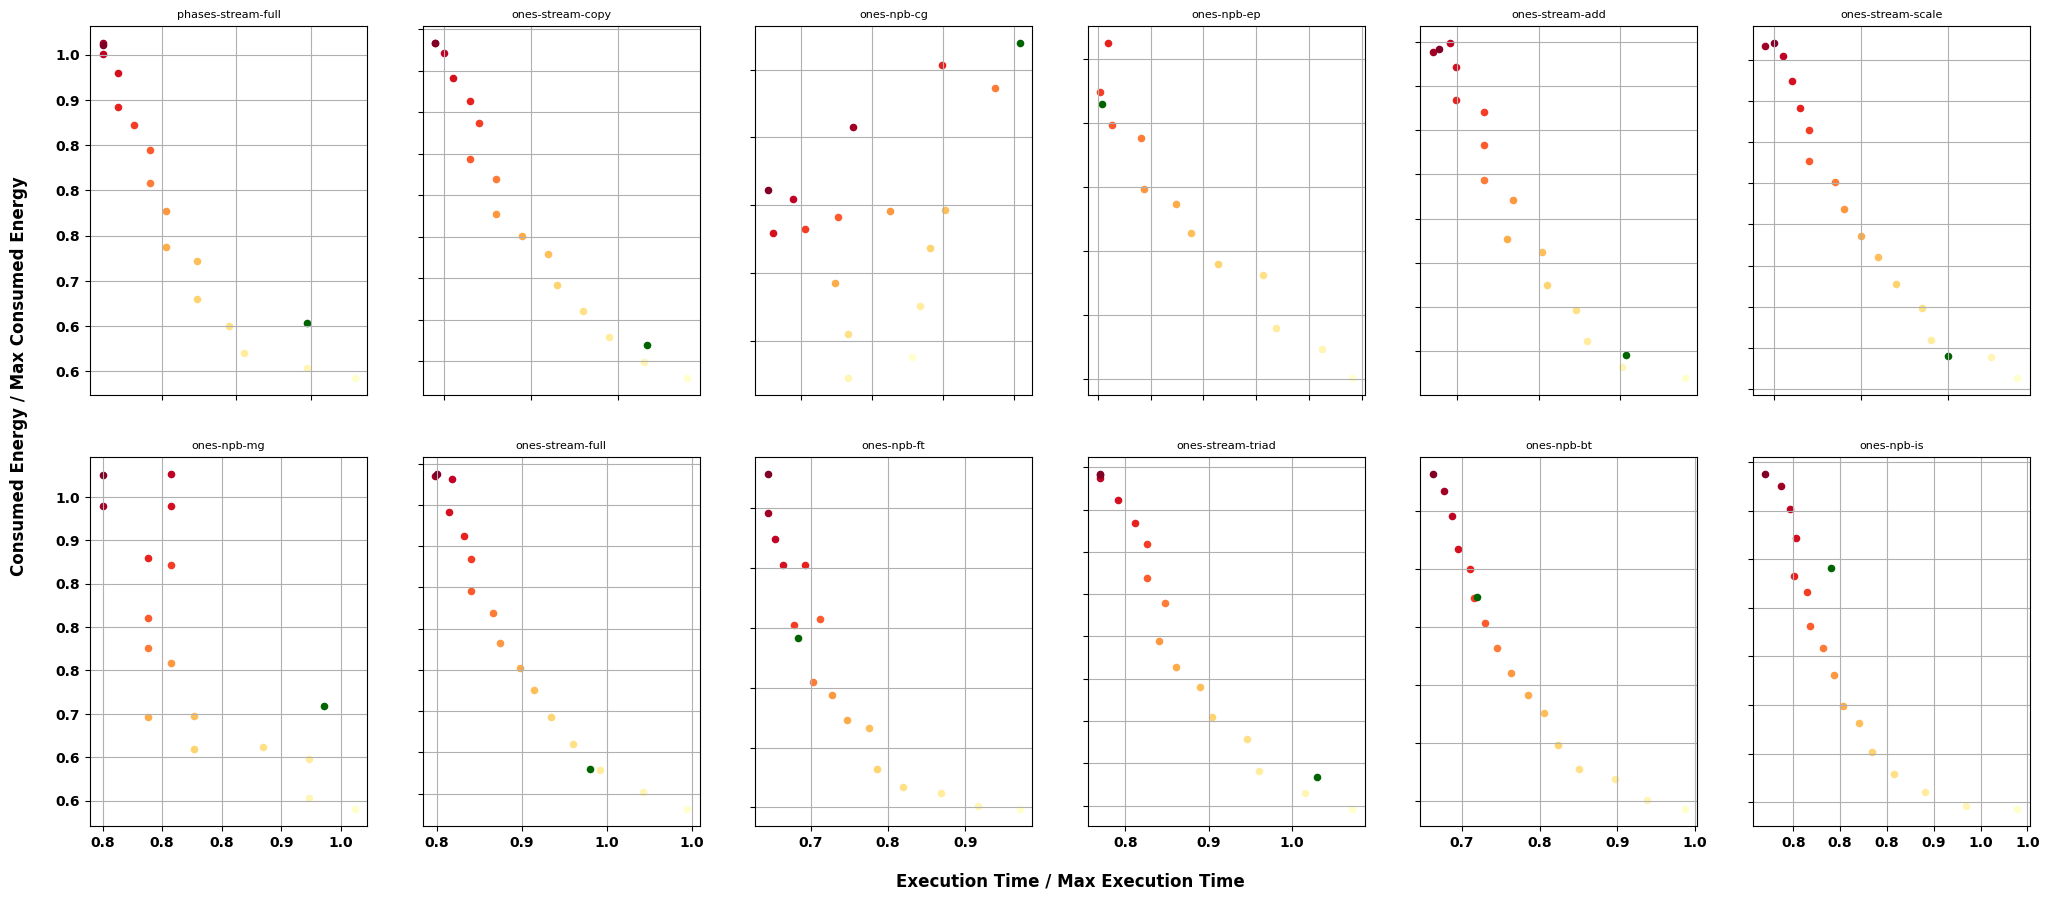

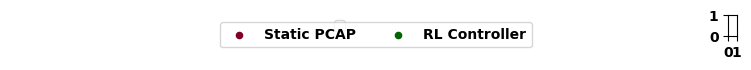

In [ ]:
# print(test_results)

index = 0


# Set up the plot layout with 2 rows and 5 columns
marker_size = 20
num_rows = 2
num_cols = 6
fig, axs = plt.subplots(num_rows, num_cols, figsize=(20, 10))  # Adjusting figsize for 2 rows and 5 columns
plt.rcParams.update({'font.size': 10, "font.weight": "bold", 'axes.labelsize': 'small'})

# Adjusting left margin more aggressively to reduce the space on the left side
plt.subplots_adjust(hspace=0.17, wspace=0.2, top=0.85, bottom=0.05, left=0.01, right=0.98)  # Further reduced left margin to 0.02
fig.text(0.5, -0.01, 'Execution Time / Max Execution Time', ha='center', fontsize=12)
fig.text(-0.03, 0.5, 'Consumed Energy / Max Consumed Energy', va='center', rotation='vertical', fontsize=12)

high_contrast_colors = plt.cm.YlOrRd(np.linspace(0, 1, 16))
sorted_keys = [78.0, 83.0, 89.0, 95.0, 101.0, 107.0, 112.0, 118.0, 124.0, 130.0, 136.0, 141.0, 147.0, 153.0, 159.0, 165.0]
norm = plt.Normalize(vmin=min(sorted_keys), vmax=max(sorted_keys)) 
smappable = plt.cm.ScalarMappable(cmap='YlOrRd', norm=norm)
smappable.set_array([])  # Dummy array to initiate ScalarMappable (not used to plot)



from collections import defaultdict
for app in test_results.keys():
    grouped_traces = defaultdict(list)
    max_execution_time = max([test_results[app][trace]['power']['average_power']['elapsed_time'].iloc[-1] for trace in test_results[app].keys()])
    max_energy_consumption = max([compute_energy_consump(test_results[app][trace]['power'])/1000 for trace in test_results[app].keys()])
    for trace in test_results[app].keys():
        grouped_traces[test_results[app][trace]['PCAP'].value.mean()].append(trace)
        # computed_energy = compute_energy_consump(test_results[app][trace]['power'])/1000
        # axs[index//num_cols, index%num_cols].scatter(test_results[app][trace]['power']['average_power']['elapsed_time'].iloc[-1],computed_energy, color=high_contrast_colors[0], s=10, label = "Static PCAP")
        # if "ones-stream-triad" in app and (test_results[app][trace]['power']['average_power']['elapsed_time'].iloc[-1] > 80) and computed_energy > 8:
        #     print(trace)
    # print(grouped_traces.keys())
    for i,PCAP_traces in enumerate(sorted(grouped_traces.keys())):     
        # print(app,trace) 
        # if app == 'ones-stream-add':
        #     pass  
        computed_energy = np.mean([compute_energy_consump(test_results[app][PCAP_trace]['power']) for PCAP_trace in grouped_traces[PCAP_traces]])/1000 
        execution_time = np.mean([test_results[app][PCAP_trace]['power']['average_power']['elapsed_time'].iloc[-1] for PCAP_trace in grouped_traces[PCAP_traces]])
        axs[index//num_cols, index%num_cols].scatter(execution_time/max_execution_time,computed_energy/max_energy_consumption,color=high_contrast_colors[i], s=marker_size, label = "Static PCAP")
    axs[index//num_cols, index%num_cols].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))  # Change format as needed
    axs[index//num_cols, index%num_cols].set_title(app, fontsize=8, loc='center')
    axs[index//num_cols, index%num_cols].grid(True)

    # index += 1


# index = 0
# for app in test_results_control.keys():
    # for trace in test_results_control[app].keys():
    computed_energy = np.mean([compute_energy_consump(test_results_control[app][trace]['power'])/1000 for trace in test_results_control[app].keys()])
    execution_time = np.mean([test_results_control[app][trace]['power']['average_power']['elapsed_time'].iloc[-1] for trace in test_results_control[app].keys()])
    axs[index//num_cols, index%num_cols].scatter(execution_time/max_execution_time, computed_energy/max_energy_consumption, color='darkgreen', s=marker_size, label = "RL Controller")
    axs[index//num_cols, index%num_cols].yaxis.set_major_formatter(FuncFormatter(lambda x, _: round(x, 1)))    
    axs[index//num_cols, index%num_cols].xaxis.set_major_formatter(FuncFormatter(lambda x, _: round(x, 1)))  
    index += 1



handles, labels = axs[0,0].get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))     

for i in range(num_rows):
    for j in range(num_cols):
        if j > 0:
            axs[i, j].set_yticklabels([])
        if i == 0:
            axs[i, j].set_xticklabels([])
plt.savefig(f'{OUTPUT_DIR}/comparison_mean.pdf', format='pdf', bbox_inches='tight')  # Save the figure

fig_leg, ax_leg = plt.subplots(figsize=(8.5,0.3))

ax_leg.legend(loc='center')

ax_leg.axis('off')
fig_leg.legend(unique_labels.values(), unique_labels.keys(), loc='center', ncol=5)
cbar_ax = fig_leg.add_axes([0.97, 0.15, 0.01, 0.7])

plt.savefig(f'{OUTPUT_DIR}/legend_only.pdf', format='pdf', bbox_inches='tight')
plt.show()



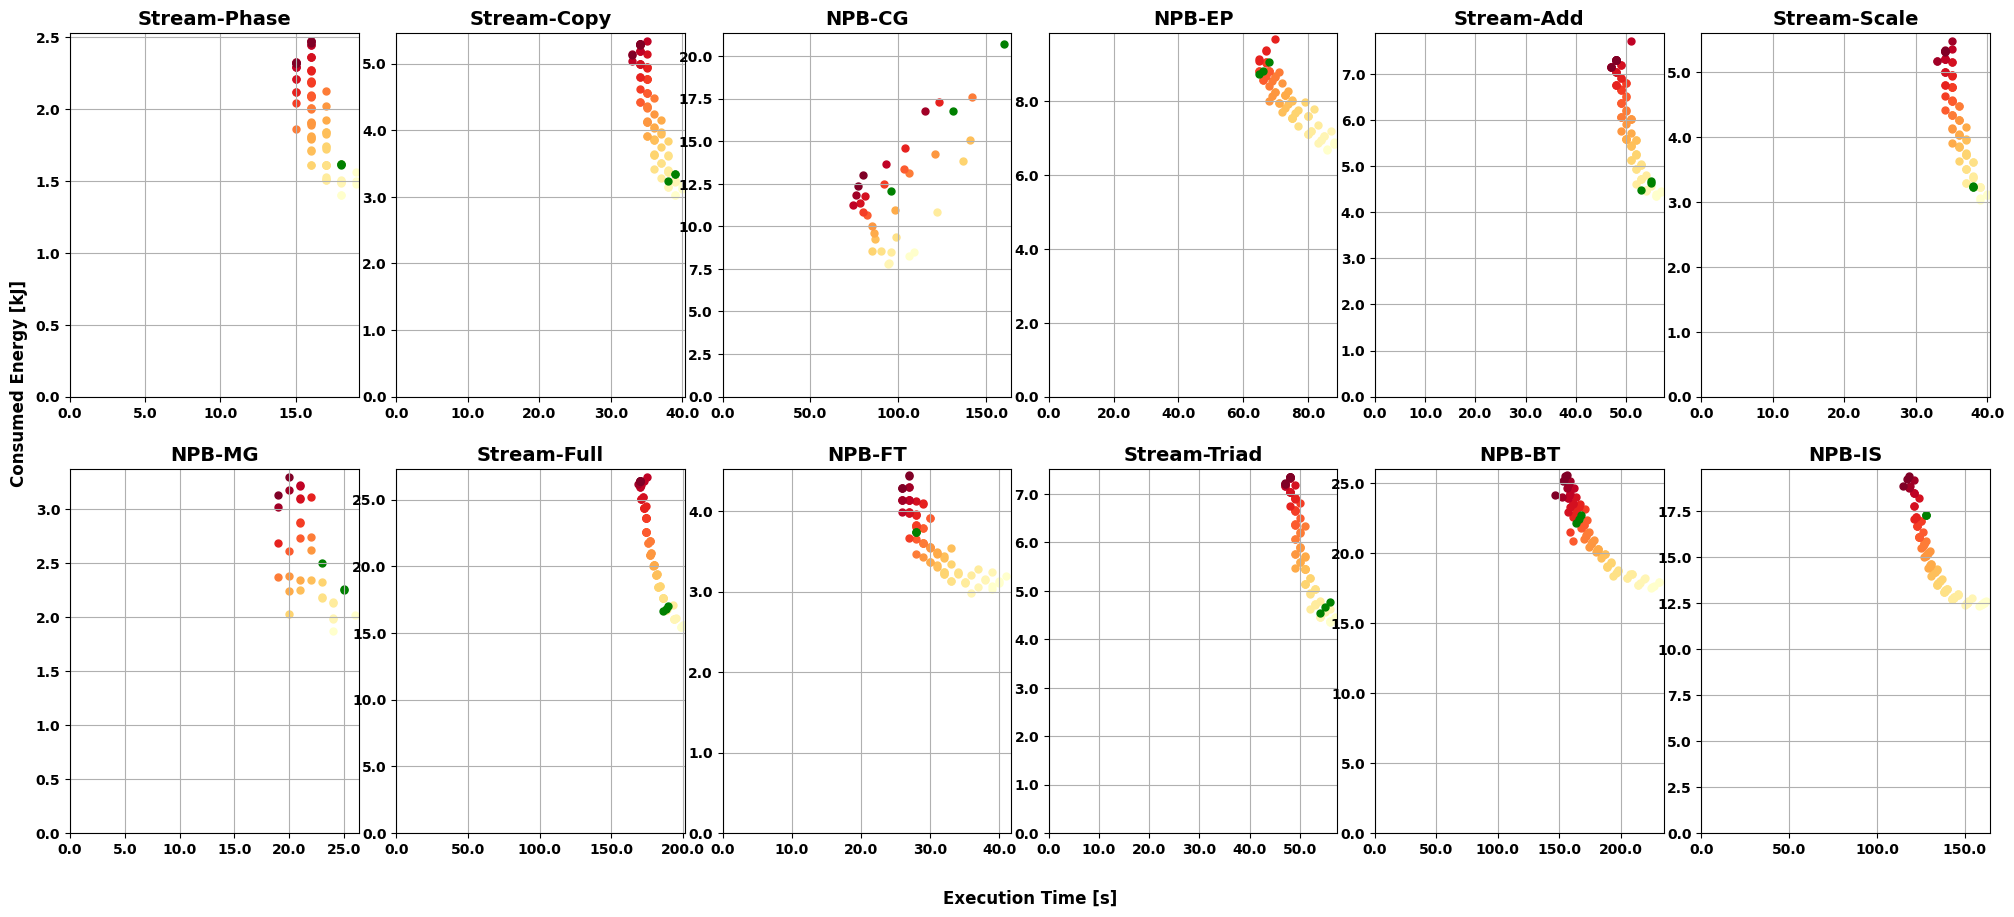

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib import ticker
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import FuncFormatter

# Set up the plot layout with 2 rows and 5 columns
marker_size = 20
num_rows = 2
num_cols = 6
fig, axs = plt.subplots(num_rows, num_cols, figsize=(20, 10))  # Adjusting figsize for 2 rows and 5 columns

# Apply the same font style, size, and spacing as the provided code
plt.rcParams.update({'font.size': 10, "font.weight": "bold", 'axes.labelsize': 'small'})

# Adjusting left margin more aggressively to reduce the space on the left side
plt.subplots_adjust(hspace=0.2, wspace=0.13, top=0.85, bottom=0.05, left=0.02, right=0.98)  # Further reduced left margin to 0.02
fig.text(0.5, -0.02, 'Execution Time [s]', ha='center', fontsize=12, fontweight='bold')
fig.text(-0.01, 0.5, 'Consumed Energy [kJ]', va='center', rotation='vertical', fontsize=12, fontweight='bold')

# High contrast colors and normalization for the color map
high_contrast_colors = plt.cm.YlOrRd(np.linspace(0, 1, 16))
sorted_keys = [78.0, 83.0, 89.0, 95.0, 101.0, 107.0, 112.0, 118.0, 124.0, 130.0, 136.0, 141.0, 147.0, 153.0, 159.0, 165.0]
norm = Normalize(vmin=min(sorted_keys), vmax=max(sorted_keys))
smappable = ScalarMappable(cmap='YlOrRd', norm=norm)
smappable.set_array([])

# Mapping the application names as per the table
# app_name_mapping = {
#     'ones-npb-ft': 'NPB-FT',
#     'ones-npb-is': 'NPB-IS',
#     'ones-stream-triad': 'Stream-Triad',
#     'ones-stream-scale': 'Stream-Scale',
#     'ones-stream-copy': 'Stream-Copy',
#     'ones-stream-add': 'Stream-Add',
#     'ones-stream-full': 'Stream-Full',
#     'ones-npb-ep': 'NPB-EP',
#     'ones-stream-phase': 'Stream-Phase',
#     'ones-npb-mg': 'NPB-MG'
# }

# For each application in test_results
index = 0
for app in test_results.keys():
    grouped_traces = defaultdict(list)
    max_execution_time = 1  # Set max execution time for normalization
    max_energy_consumption = 1  # Set max energy consumption for normalization

    for trace in test_results[app].keys():
        # Collect traces based on the PCAP value
        grouped_traces[test_results[app][trace]['PCAP'].value.mean()].append(trace)

    for i, PCAP_traces in enumerate(sorted(grouped_traces.keys())):
        # Plot each trace's execution time and energy consumption
        for trace in grouped_traces[PCAP_traces]:
            computed_energy = compute_energy_consump(test_results[app][trace]['power']) / 1000
            execution_time = test_results[app][trace]['power']['average_power']['elapsed_time'].iloc[-1]
            axs[index // num_cols, index % num_cols].scatter(execution_time / max_execution_time, computed_energy / max_energy_consumption,
                                                              color=high_contrast_colors[i], s=25)

    # Add RL Controller scatter plots
    if app in test_results_control:
        for trace in test_results_control[app].keys():
            computed_energy = compute_energy_consump(test_results_control[app][trace]['power']) / 1000
            execution_time = test_results_control[app][trace]['power']['average_power']['elapsed_time'].iloc[-1]
            axs[index // num_cols, index % num_cols].scatter(execution_time / max_execution_time, computed_energy / max_energy_consumption,
                                                              color='green', s=25, label="RL Controller")
    
    # Use the mapping to update the title with the correct name
    axs[index // num_cols, index % num_cols].set_title(app_name_mapping.get(app, app), fontsize=14, loc='center', fontweight='bold')
    axs[index // num_cols, index % num_cols].grid(True)
    axs[index // num_cols, index % num_cols].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))  # Formatting axis
    axs[index // num_cols, index % num_cols].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: round(x, 1)))  # Formatting y-axis
    
    # Set tick labels bold and increase their size
    for label in axs[index // num_cols, index % num_cols].get_xticklabels() + axs[index // num_cols, index % num_cols].get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(10)

    # Set consistent x-axis range for all subplots
    axs[index // num_cols, index % num_cols].set_xlim(left=0)  # Set x-axis lower limit to 0
    axs[index // num_cols, index % num_cols].set_ylim(bottom=0)  # Set y-axis lower limit to 0

    index += 1

# Save the plot to a file
plt.savefig(f'{OUTPUT_DIR}/comparison_scatter_with_rl_2rows5cols_updated_titles_ticks_increased_size.pdf', format='pdf', bbox_inches='tight')
plt.show()


In [ ]:
stats = {}
for app in test_results.keys():
    stats[app] = {}
    stats[app]["MAX"] = {}
    stats[app]["MIN"] = {}
    stats[app]["MAX"]['ET'] = []
    stats[app]["MAX"]['ENERGY'] = []
    stats[app]["MIN"]['ET'] = []
    stats[app]["MIN"]['ENERGY'] = []
    for trace in test_results[app].keys():
        if test_results[app][trace]['PCAP'].value.mean() > 164:
            exp = "MAX"
        else:
            exp = "MIN"
        # print(exp)
        stats[app][exp]['ET'].append(test_results[app][trace]['power']['average_power']['elapsed_time'].iloc[-1])
        stats[app][exp]['ENERGY'].append(compute_energy_consump(test_results[app][trace]['power'])/1000)
# for app in stats.keys():
#     for exp in stats[app].keys():
#         for para in stats[app][exp].keys(): 
#             print(f"{app}-----{exp}-----{para}.................{np.mean(stats[app][exp][para])}--------------------{np.std(stats[app][exp][para])}")
                    
# stats = {}
for app in test_results_control.keys():
    # stats[app] = {}
    stats[app]["OPT"] = {}
    stats[app]["OPT"] = {}
    stats[app]["OPT"]['ET'] = []
    stats[app]["OPT"]['ENERGY'] = []
    for trace in test_results_control[app].keys():
        stats[app]["OPT"]['ET'].append(test_results_control[app][trace]['power']['average_power']['elapsed_time'].iloc[-1])
        stats[app]["OPT"]['ENERGY'].append(compute_energy_consump(test_results_control[app][trace]['power'])/1000)
MAX = {}
MIN = {}
RL = {}
for app in stats.keys():
    for exp in stats[app].keys():
        for para in stats[app][exp].keys(): 
            # stats[app][exp][para]['mean'] = np.mean(stats[app][exp][para])
            # stats[app][exp][para]['std'] = np.std(stats[app][exp][para])
            print(f"{app}-----{exp}-----{para}................mean:{np.mean(stats[app][exp][para])}--------------------std:{np.std(stats[app][exp][para])}")
            if exp == "MAX":
                MAX[app] = (np.mean(stats[app][exp][para]),np.std(stats[app][exp][para]))
            elif exp == "MIN":
                MIN[app] = (np.mean(stats[app][exp][para]),np.std(stats[app][exp][para]))
            elif exp == "OPT":
                RL[app] = (np.mean(stats[app][exp][para]),np.std(stats[app][exp][para]))
            else:
                print("Something wrong")
            

import pickle  # Add this import at the top

with open('./figures/stats_export.pkl', 'wb') as f:  # Export to a file named 'stats_export.pkl'
    pickle.dump({'MAX': MAX, 'MIN': MIN, 'RL': RL}, f)  # Save the dictionaries

stats_list = []

for app in stats.keys():
    for exp in stats[app].keys():
        for param in stats[app][exp].keys():
            mean_value = np.mean(stats[app][exp][para])
            std_value = np.std(stats[app][exp][para])
            # print(mean_value,std_value)
            stats_list.append({
                'App': app,
                'Type': exp,
                'Parameter': param,
                'Mean': mean_value,
                'Std': std_value
            })

# Convert the list of dictionaries to a DataFrame
stats_df = pd.DataFrame(stats_list)

# Saving the DataFrame to a CSV file
stats_df.to_csv('./figures/stats_summary.csv', index=False)   

phases-stream-full-----MAX-----ET................mean:15.400064086914062--------------------std:0.48998015689256474
phases-stream-full-----MAX-----ENERGY................mean:2.377067373731746--------------------std:0.07304560034673119
phases-stream-full-----MIN-----ET................mean:16.41327846209208--------------------std:1.007882763155473
phases-stream-full-----MIN-----ENERGY................mean:1.9218035058736023--------------------std:0.3147057162552276
phases-stream-full-----OPT-----ET................mean:18.00001311302185--------------------std:8.766544490265958e-06
phases-stream-full-----OPT-----ENERGY................mean:1.6166220420470754--------------------std:0.0034859450080462918
ones-stream-copy-----MAX-----ET................mean:33.79996519088745--------------------std:0.400034572406926
ones-stream-copy-----MAX-----ENERGY................mean:5.256956268706732--------------------std:0.06314625098534132
ones-stream-copy-----MIN-----ET................mean:35.89329658190

In [ ]:
metrics = {}
for app in test_results.keys():
    metrics[app] = {}
    metrics[app]['ET'] = []
    metrics[app]['IPC'] = []
    metrics[app]['progress'] = []
    metrics[app]['STL'] = []
    metrics[app]['CMR'] = []
    for trace in test_results[app].keys():
        metrics[app]['ET'].append(test_results[app][trace]['power']['average_power']['elapsed_time'].iloc[-1])
        metrics[app]['IPC'].append(test_results[app][trace]['derived_papi']['TOT_INS_PER_CYC'].value.mean())
        metrics[app]['STL'].append(test_results[app][trace]['derived_papi']['TOT_STL_PER_CYC'].value.mean())
        metrics[app]['CMR'].append(test_results[app][trace]['derived_papi']['L3_TCM_PER_TCA'].value.mean())
        metrics[app]['progress'].append(test_results[app][trace]['progress']['progress_frequency_median']['median'].mean())
    for para in metrics[app].keys():
        print(f"{app}-----------------{para}.................{np.mean(metrics[app][para])}")
        
control_metrics = {}
for app in test_results_control.keys():
    control_metrics[app] = {}
    control_metrics[app]['ET'] = []
    control_metrics[app]['IPC'] = []
    control_metrics[app]['progress'] = []
    control_metrics[app]['STL'] = []
    control_metrics[app]['CMR'] = []
    for trace in test_results_control[app].keys():
        control_metrics[app]['ET'].append(test_results_control[app][trace]['power']['average_power']['elapsed_time'].iloc[-1])
        control_metrics[app]['IPC'].append(test_results_control[app][trace]['derived_papi']['TOT_INS_PER_CYC'].value.mean())
        control_metrics[app]['STL'].append(test_results_control[app][trace]['derived_papi']['TOT_STL_PER_CYC'].value.mean())
        control_metrics[app]['CMR'].append(test_results_control[app][trace]['derived_papi']['L3_TCM_PER_TCA'].value.mean())
        control_metrics[app]['progress'].append(test_results_control[app][trace]['progress']['progress_frequency_median']['median'].mean())
    # for para in control_metrics[app].keys():
        # print(f"{app}-----------------{para}.................{np.mean(metrics[app][para])}")

phases-stream-full-----------------ET.................16.349952563643456
phases-stream-full-----------------IPC.................0.17599638766331574
phases-stream-full-----------------progress.................223.21583336685185
phases-stream-full-----------------STL.................0.8750435492610592
phases-stream-full-----------------CMR.................0.9188517762017316
ones-stream-copy-----------------ET.................35.76246336996555
ones-stream-copy-----------------IPC.................0.17730353526560738
ones-stream-copy-----------------progress.................268.31514517999165
ones-stream-copy-----------------STL.................0.8794196267733486
ones-stream-copy-----------------CMR.................0.8883121966559514
ones-npb-cg-----------------ET.................98.65625846385956
ones-npb-cg-----------------IPC.................0.4889807983450466
ones-npb-cg-----------------progress.................10.314583790791096
ones-npb-cg-----------------STL.................0.6947317

In [ ]:
from collections import defaultdict

for app in test_results.keys():
    grouped_traces = defaultdict(list)
    mean_TCM = []
    for trace in test_results[app].keys():
        # Collect traces based on the PCAP value
        grouped_traces[test_results[app][trace]['PCAP'].value.mean()].append(trace)

    for i, PCAP_traces in enumerate(sorted(grouped_traces.keys())):
        # Plot each trace's execution time and energy consumption
        if PCAP_traces == 165.0:
            for trace in grouped_traces[PCAP_traces]:
                # print(app)
                mean_TCM.append(test_results[app][trace]['papi']['PAPI_L3_TCM']['instantaneous_value'].mean())
                # print(f"{app}..{PCAP_traces}.........",test_results[app][trace]['papi']['PAPI_L3_TCM']['instantaneous_value'].mean())
    print(app,np.mean(mean_TCM))

phases-stream-full 2036882979.8222222
ones-stream-copy 2010171351.7629128
ones-npb-cg 1673252252.085691
ones-npb-ep nan
ones-stream-add 2317973261.5280004
ones-stream-scale 2010138303.7516518
ones-npb-mg 1490870344.4791665
ones-stream-full 2266299782.327981
ones-npb-ft 794476218.8884237
ones-stream-triad 2317030434.5880003
ones-npb-bt 577045039.532232
ones-npb-is 1336387831.6096153
